# Unemployment Rate Forecasting Pipeline — Republic of Kazakhstan

**Enhanced Production-Ready Pipeline for Diploma Defense**

This notebook implements an end-to-end macroeconomic forecasting pipeline covering:
1. Data Assessment & Integration
2. Rigorous EDA (ADF, KPSS, STL, ACF/PACF)
3. Advanced Feature Engineering (Fourier, Lags, Rolling Stats, Interactions, Regime Dummies, PCA)
4. Hybrid Model Stack (8 models: SARIMAX, VAR, ARDL, XGBoost, Prophet, Random Forest, ANN, LSTM)
5. Walk-Forward Cross-Validation
6. Defense-Ready Visualizations

---

In [34]:
%pip install --default-timeout=1000 statsmodels scikit-learn tensorflow xgboost prophet yfinance openpyxl -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# ============================================================
# Cell 1: Imports & Configuration
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, re, os
from itertools import product as iter_product

# Statsmodels
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Scikit-learn
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

# XGBoost
import xgboost as xgb

# Prophet
from prophet import Prophet

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Publication-quality plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.labelsize': 13,
    'font.size': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

PALETTE = {
    'SARIMA':   '#1f77b4', 'SARIMAX':  '#ff7f0e', 'VAR':      '#2ca02c',
    'ARDL':     '#d62728', 'ElasticNet':'#9467bd', 'XGBoost':  '#8c564b',
    'Prophet':  '#e377c2', 'RF':       '#7f7f7f', 'ANN':      '#bcbd22',
    'LSTM':     '#17becf',
}
DATA = './data/'
FIGURES = './figures/'
os.makedirs(FIGURES, exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading & Integration

### 1.1 Data Assessment & Recommendations

**Current Target Variable:** Monthly unemployment rate (%), Jan 2010 -- Dec 2025 (192 obs.)

**Assessment:**
- 192 monthly observations is *adequate* for SARIMAX/VAR (rule of thumb: $n > 5p$ where $p$ is number of parameters).
- For deep learning (LSTM), 192 is tight but workable with proper regularization and small architectures.
- The 108-month training window and 24-month test is a valid 82/18 split.

**Recommended Exogenous Indicators:**

| Priority | Indicator | Rationale | Source |
|----------|-----------|-----------|--------|
| **Must-have** | Oil price (Brent) | KZ is oil-dependent; oil shocks drive fiscal/employment cycles | FRED |
| **Must-have** | USD/KZT exchange rate | Currency depreciation affects import-dependent sectors | NBK |
| **Must-have** | NBK base rate | Monetary policy transmission to credit/investment/employment | NBK |
| **Must-have** | GDP growth (YoY %) | Okun's law: $\Delta u \approx -0.5 \Delta y$ | stat.gov.kz |
| **High** | RUB/KZT cross-rate | Russia is KZ's largest trade partner | Derived |
| **High** | CPI (aggregated via PCA) | Wage-price spiral, cost-push unemployment | stat.gov.kz |
| **High** | Gold price | Second major export commodity, fiscal hedge | FRED |
| **Medium** | Industrial Production Index | Leading indicator for manufacturing employment | stat.gov.kz |
| **Medium** | STEI (Short-Term Economic Indicator) | Composite leading indicator | stat.gov.kz |
| **Medium** | Retail Trade Volume | Proxy for aggregate demand / services employment | stat.gov.kz |
| **Low** | Labor force participation rate | Structural labor market shifts | stat.gov.kz |

**Regional Data:** Not recommended for this scope. Oblast-level data introduces panel complexity (16 oblasts x 192 months) without proportional gain for a univariate national forecast. Mention in "Future Work" section of your thesis.

In [37]:
# ============================================================
# Cell 2: Load Primary Dataset
# ============================================================
raw = pd.read_excel(DATA + 'cpi_data/diploma_dataset.xlsx')
raw['Date'] = pd.to_datetime(raw['Date'])
raw = raw.set_index('Date').sort_index()
raw = raw.rename(columns={'Unemployement': 'unemployed_rate'})

# Separate CPI sub-indices for PCA later
macro_cols = ['gold_price_usd_avg', 'usd_kzt', 'interest_rate',
              'Oil_crude_brent', 'GDP_growth', 'unemployed_rate']
cpi_cols = [c for c in raw.columns if c not in macro_cols]
cpi_df = raw[cpi_cols].copy()  # Preserve for PCA

df = raw[macro_cols].copy()
print(f'Primary dataset: {df.shape[0]} months x {df.shape[1]} columns')
print(f'CPI sub-indices preserved for PCA: {len(cpi_cols)} columns')
print(f'Date range: {df.index.min().date()} -> {df.index.max().date()}')

Primary dataset: 192 months x 6 columns
CPI sub-indices preserved for PCA: 13 columns
Date range: 2010-01-01 -> 2025-12-01


In [38]:
# ============================================================
# Cell 3: Integrate Additional Data Sources
# ============================================================

# ── NBK Base Rate (irregular -> monthly) ──
nbk = pd.read_excel(DATA + 'unemp/National Bank Base Rate.xlsx')
nbk.columns = ['Date_str', 'Base_Rate', 'Corridor']
nbk = nbk.dropna(subset=['Base_Rate'])
nbk['Date'] = pd.to_datetime(
    nbk['Date_str'].str.replace('*', '', regex=False),
    format='%d.%m.%Y', dayfirst=True, errors='coerce')
nbk['Base_Rate'] = nbk['Base_Rate'].astype(str).str.replace(',', '.').astype(float)
nbk = nbk[['Date', 'Base_Rate']].dropna().set_index('Date').sort_index()
nbk_monthly = nbk.resample('MS').ffill()
df = df.join(nbk_monthly, how='left')
df['Base_Rate'] = df['Base_Rate'].bfill()

# ── USD/KZT daily -> monthly mean + volatility ──
usd_raw = pd.read_excel(DATA + 'unemp/USD_TENGE.xlsx')
_date = pd.to_datetime(usd_raw.iloc[:, 0], dayfirst=True, errors='coerce')
_quant = pd.to_numeric(usd_raw.iloc[:, 1], errors='coerce').fillna(1)
_tenge = pd.to_numeric(usd_raw.iloc[:, 2], errors='coerce')
_rate = (_tenge / _quant)
usd_daily = pd.DataFrame({'usd_kzt_daily': _rate.values}, index=_date).sort_index()
df = df.join(usd_daily.resample('MS').std().rename(
    columns={'usd_kzt_daily': 'usd_kzt_volatility'}), how='left')
df['usd_kzt_volatility'] = df['usd_kzt_volatility'].fillna(0)

# ── RUB/KZT derived from yfinance ──
import yfinance as yf
usdrub = yf.download('RUBUSD=X', start='2010-01-01', progress=False)
if usdrub.empty:
    usdrub = yf.download('RUB=X', start='2010-01-01', progress=False)

if not usdrub.empty:
    usdrub_monthly = usdrub[['Close']].resample('MS').mean()
    usdrub_monthly.columns = ['USD_RUB']
    usdrub_monthly.index.name = 'Date'
    merged_fx = usd_daily.resample('MS').mean().join(usdrub_monthly, how='inner')
    merged_fx['rub_kzt'] = merged_fx['usd_kzt_daily'] * merged_fx['USD_RUB']
    df = df.join(merged_fx[['rub_kzt']], how='left')
    print(f'Derived RUB/KZT: {df["rub_kzt"].notna().sum()} months')
else:
    rub_local = pd.read_csv(DATA + 'unemp/RUB_KZT Historical Data.csv')
    rub_local['Date'] = pd.to_datetime(rub_local['Date'])
    rub_local = rub_local.set_index('Date')[['Price']].sort_index()
    rub_local.columns = ['rub_kzt']
    df = df.join(rub_local.resample('MS').mean(), how='left')
    print(f'Local RUB/KZT fallback: {df["rub_kzt"].notna().sum()} months')

df = df.ffill().bfill()
print(f'\nIntegrated dataset: {df.shape[0]} months x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print(f'Missing: {df.isna().sum().sum()}')

Derived RUB/KZT: 190 months

Integrated dataset: 192 months x 9 columns
Columns: ['gold_price_usd_avg', 'usd_kzt', 'interest_rate', 'Oil_crude_brent', 'GDP_growth', 'unemployed_rate', 'Base_Rate', 'usd_kzt_volatility', 'rub_kzt']
Missing: 0


---
## 2. Exploratory Data Analysis (EDA) Pipeline

### 2.1 Data Validation & Descriptive Statistics

In [39]:
# ============================================================
# Cell 4: Descriptive Statistics & Missing Values
# ============================================================
print('=== Descriptive Statistics ===')
display(df.describe().T.round(3))

print('\n=== Missing Values ===')
print(df.isna().sum())

print('\n=== Frequency Validation ===')
freq_gaps = df.index.to_series().diff().dt.days
print(f'Expected monthly: min gap = {freq_gaps.min()} days, '
      f'max gap = {freq_gaps.max()} days')

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
gold_price_usd_avg,192.0,1663.028,584.000,1069.945,1271.942,1504.728,1837.395,4311.059
usd_kzt,192.0,321.138,132.027,145.446,154.597,338.987,433.460,540.749
interest_rate,192.0,10.279,3.956,5.500,7.000,9.250,14.250,18.000
Oil_crude_brent,192.0,77.561,24.068,18.380,61.037,75.305,97.960,125.450
GDP_growth,192.0,4.135,2.441,-2.490,3.842,4.395,5.322,7.400
unemployed_rate,192.0,4.996,0.306,4.600,4.800,4.900,5.125,6.300
Base_Rate,192.0,12.294,2.493,9.000,10.250,12.000,14.250,18.000
usd_kzt_volatility,192.0,2.914,4.131,0.000,0.301,1.630,3.634,29.213
rub_kzt,192.0,5.458,1.890,2.871,4.836,5.290,5.749,28.506



=== Missing Values ===
gold_price_usd_avg    0
usd_kzt               0
interest_rate         0
Oil_crude_brent       0
GDP_growth            0
unemployed_rate       0
Base_Rate             0
usd_kzt_volatility    0
rub_kzt               0
dtype: int64

=== Frequency Validation ===
Expected monthly: min gap = 28.0 days, max gap = 31.0 days


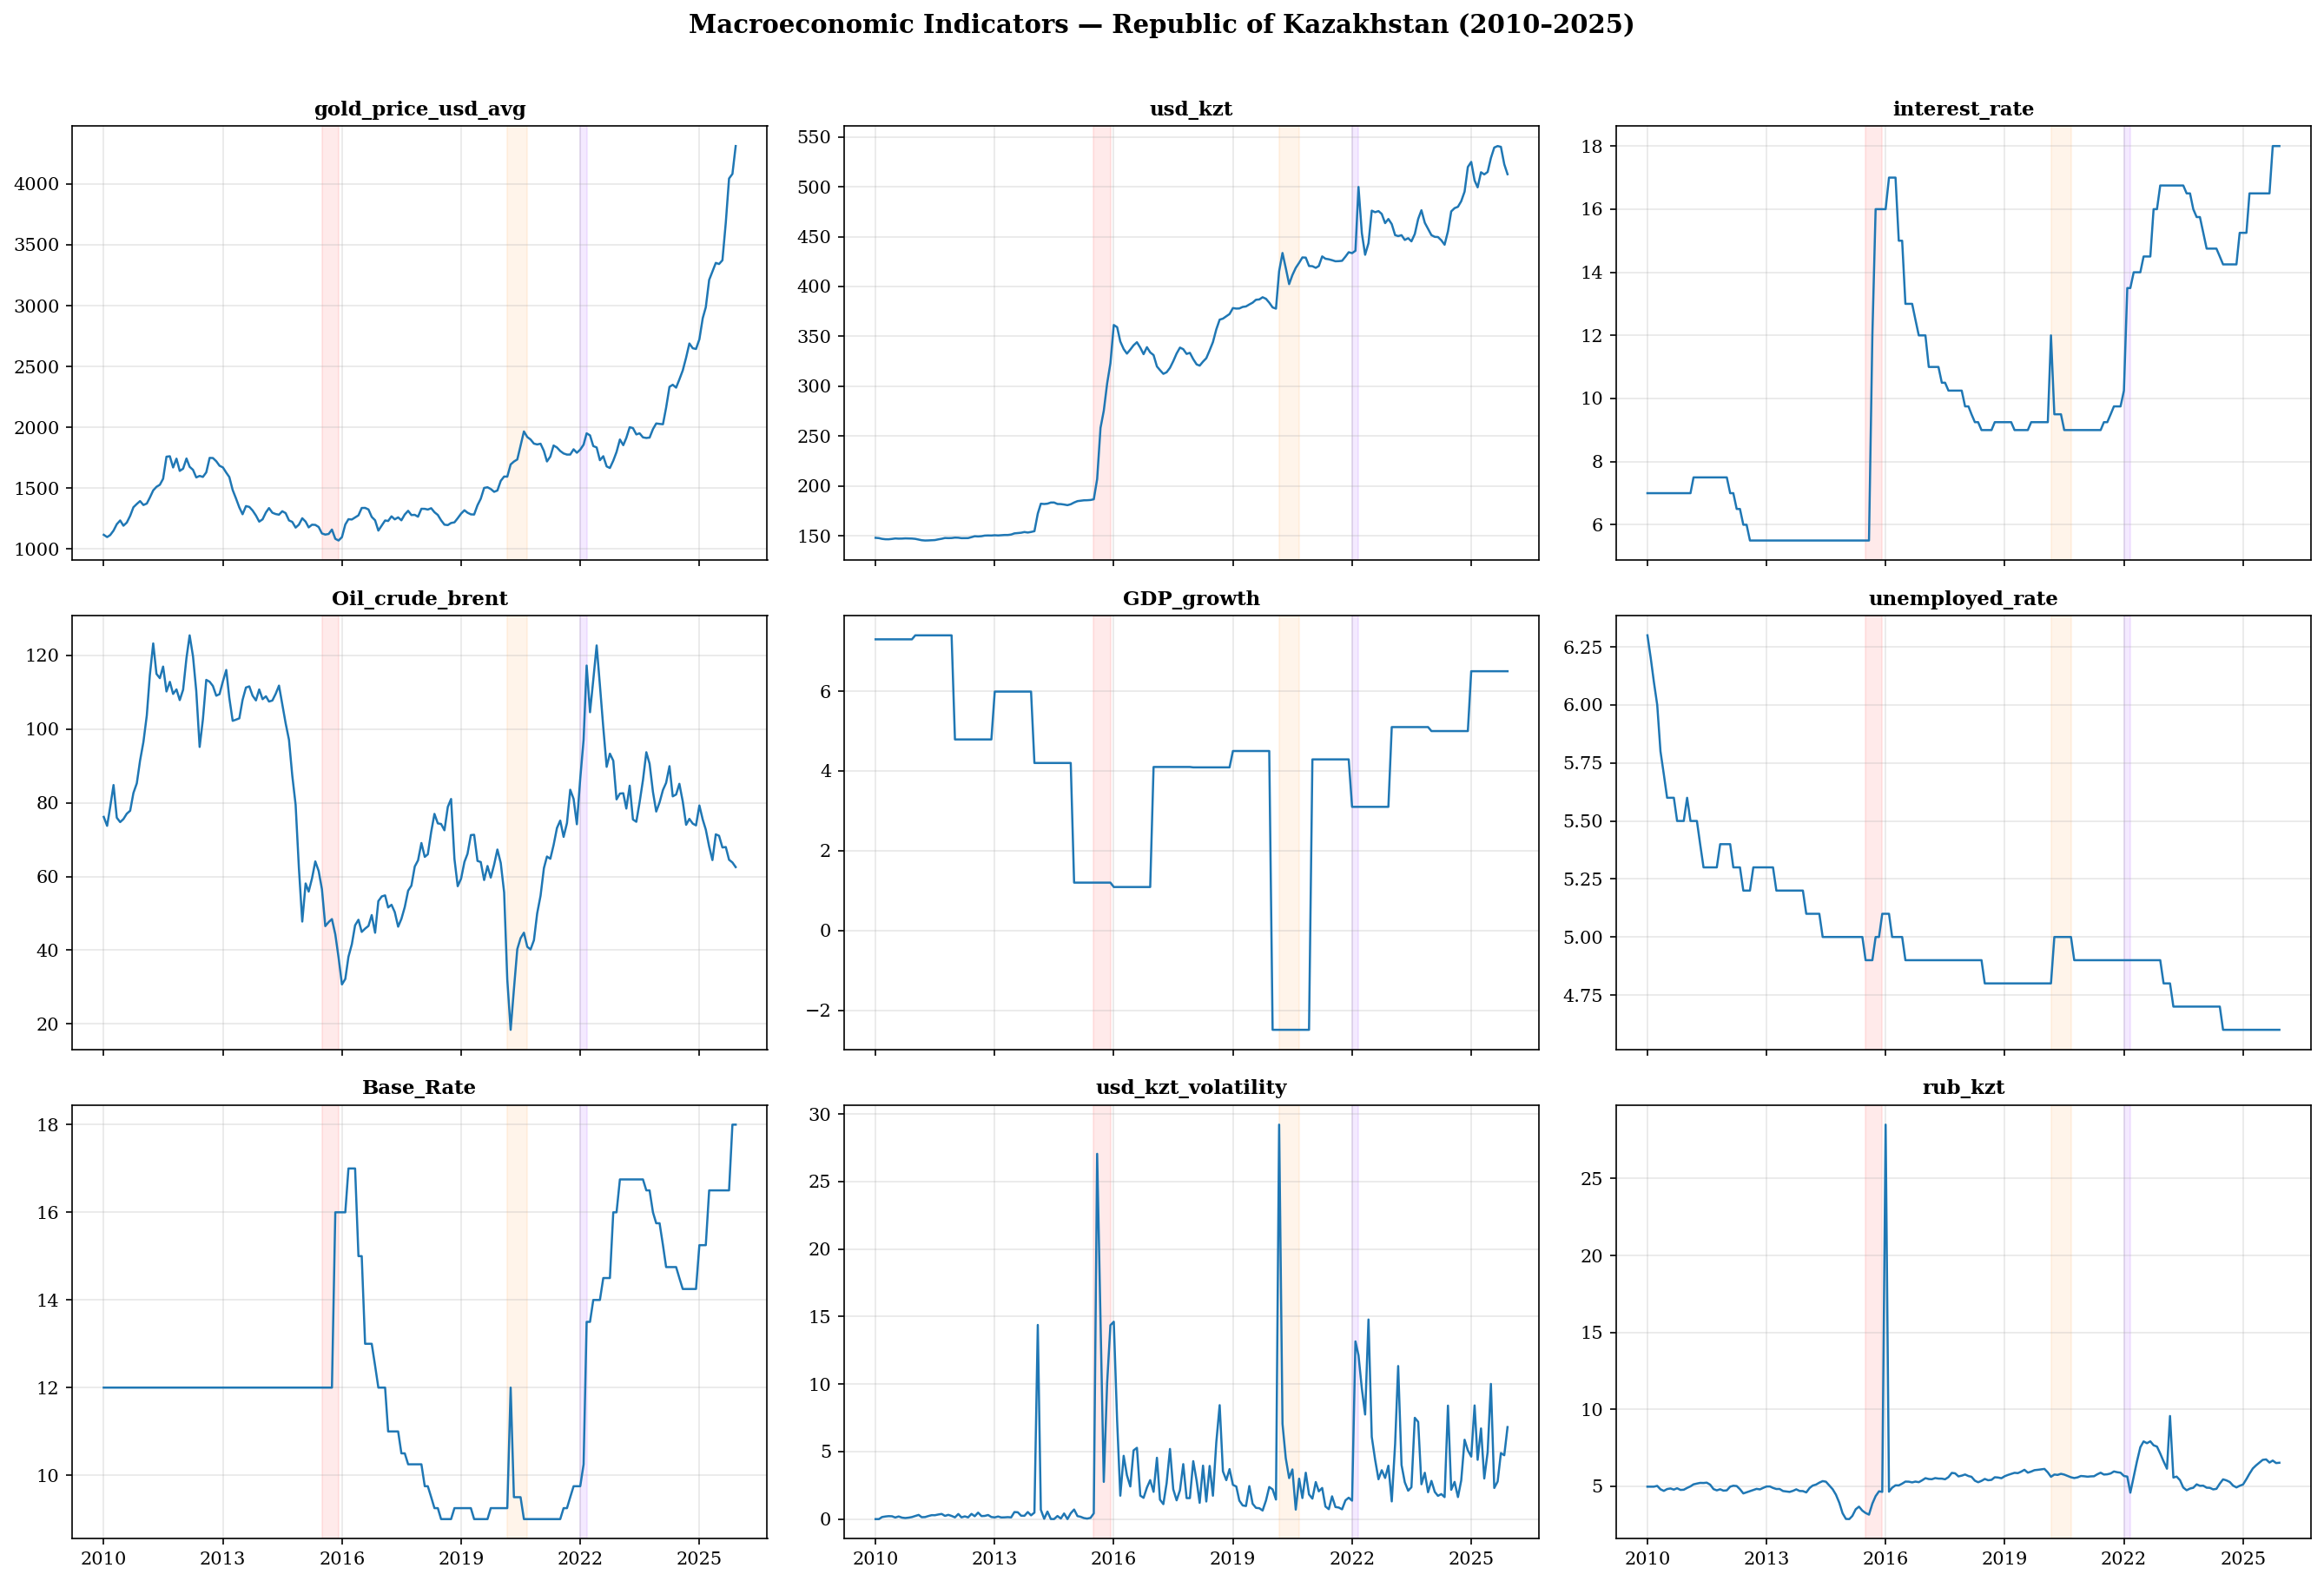

In [40]:
# ============================================================
# Cell 5: Time Series Visualization
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.flatten()
for i, col in enumerate(df.columns):
    if i >= len(axes):
        break
    axes[i].plot(df.index, df[col], lw=1.2, color='#1f77b4')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    # Shade regime periods
    for start, end, label, color in [
        ('2015-07', '2015-12', 'Tenge Float', '#ff9999'),
        ('2020-03', '2020-09', 'COVID-19', '#ffcc99'),
        ('2022-01', '2022-03', 'Jan Events', '#cc99ff'),
    ]:
        axes[i].axvspan(start, end, alpha=0.2, color=color)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Macroeconomic Indicators — Republic of Kazakhstan (2010–2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'eda_timeseries.png')
plt.show()

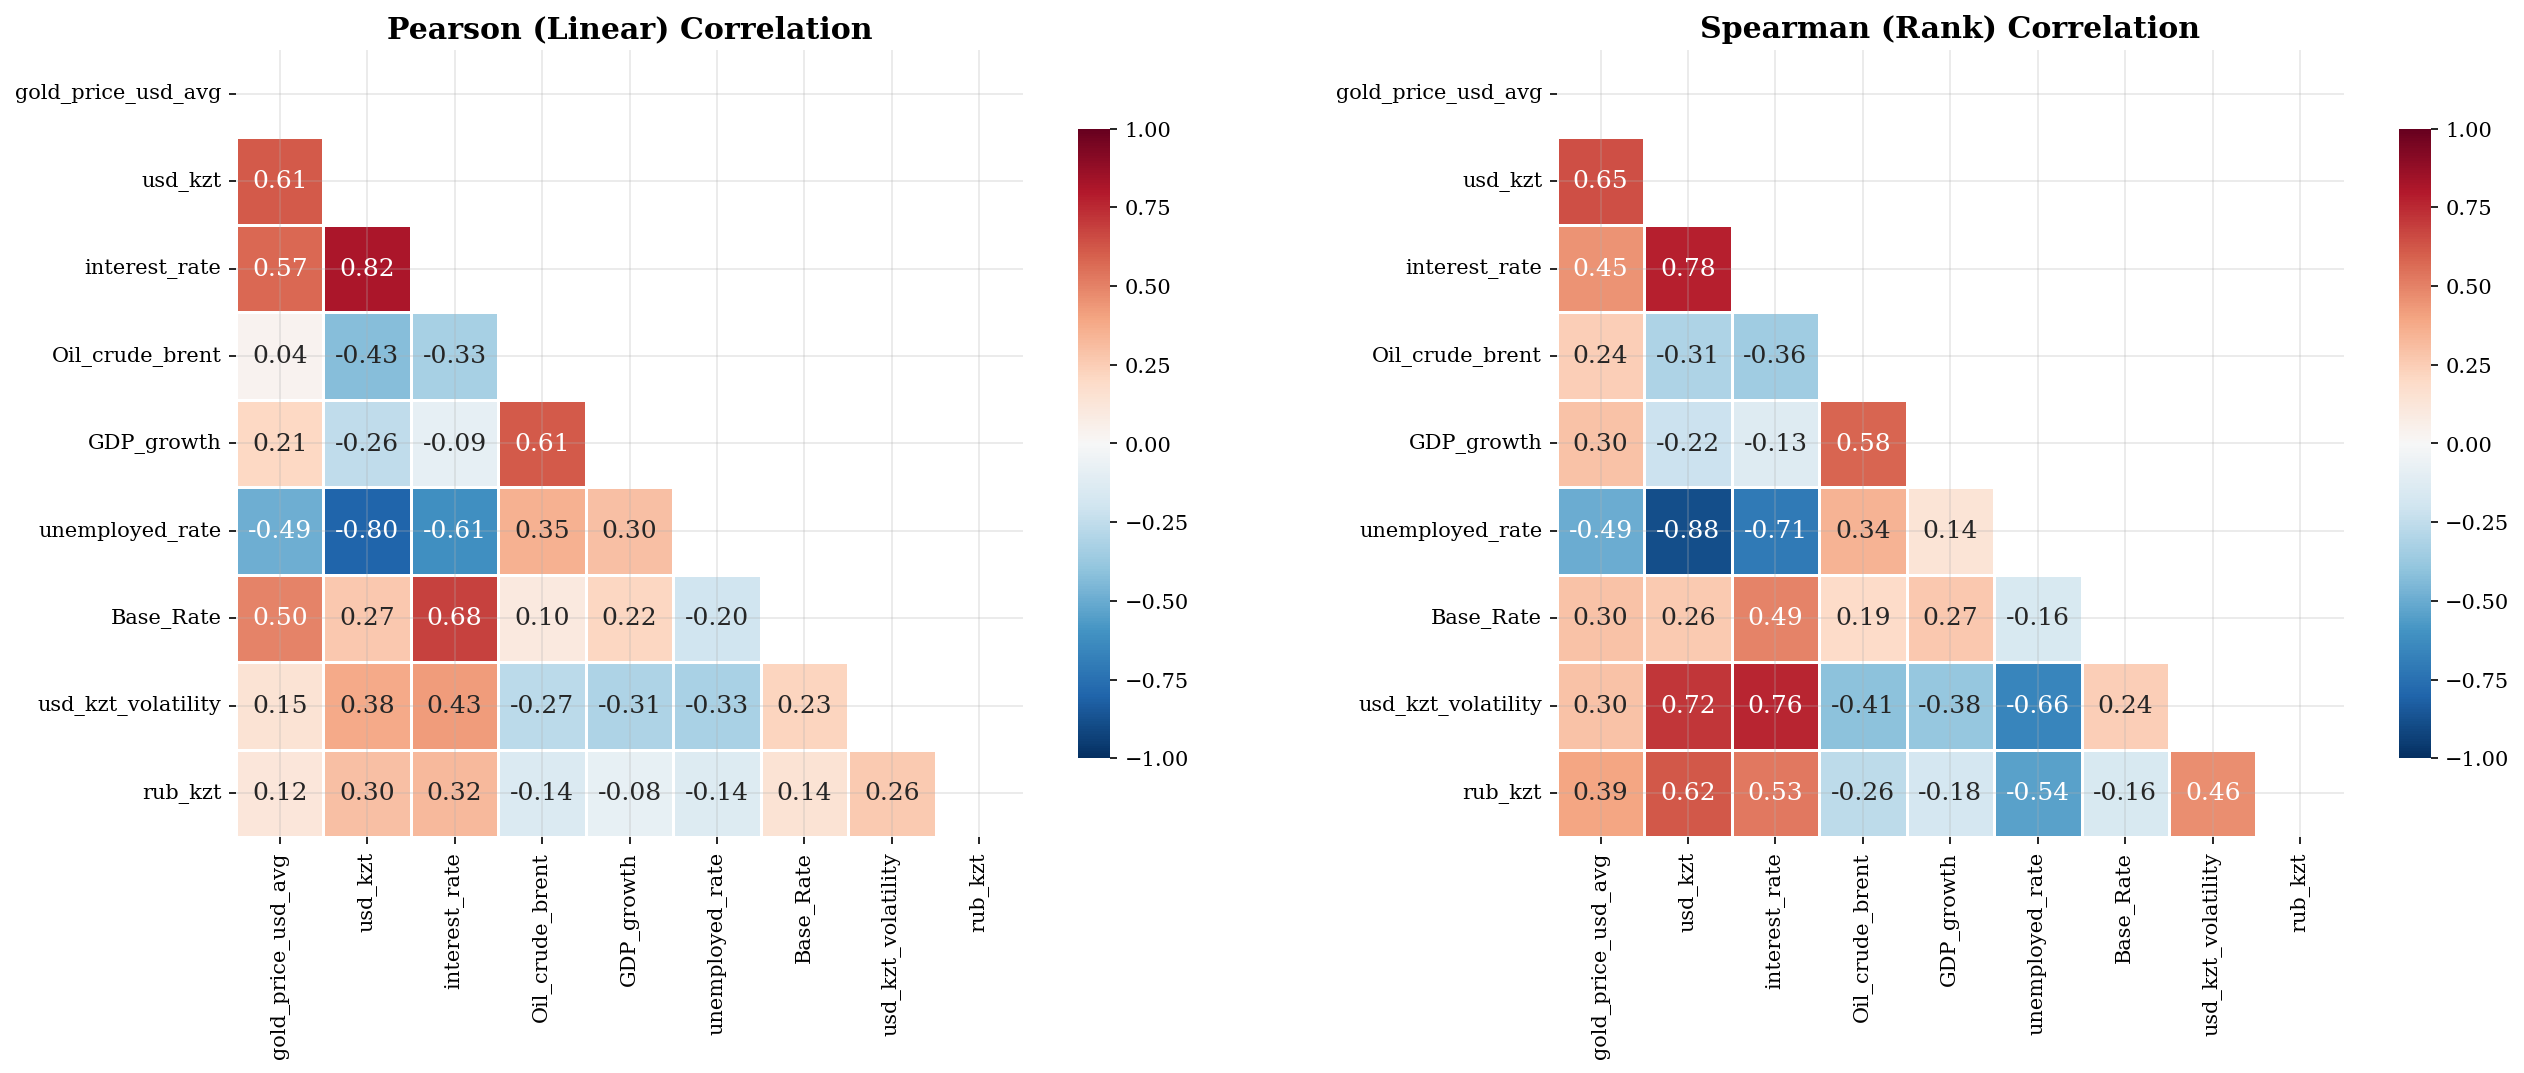

In [41]:
# ============================================================
# Cell 6: Correlation Analysis (Pearson + Spearman)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, title in zip(axes, ['pearson', 'spearman'],
                              ['Pearson (Linear)', 'Spearman (Rank)']):
    corr = df.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{title} Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES + 'eda_correlation.png')
plt.show()

### 2.2 Stationarity Testing (ADF + KPSS)

We use **both** tests for robustness:
- **ADF** ($H_0$: unit root exists → non-stationary)
- **KPSS** ($H_0$: series is stationary)

| ADF | KPSS | Conclusion |
|-----|------|------------|
| Reject | Fail to reject | **Stationary** |
| Fail to reject | Reject | **Non-stationary** |
| Both reject | — | Trend-stationary (difference) |
| Neither | — | Inconclusive |

In [42]:
# ============================================================
# Cell 7: ADF + KPSS Stationarity Tests
# ============================================================
stationarity_results = []

for col in df.columns:
    series = df[col].dropna()
    
    # ADF test
    adf_stat, adf_p, adf_lags, _, _, _ = adfuller(series, autolag='AIC')
    
    # KPSS test
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
    
    # Joint conclusion
    adf_reject = adf_p < 0.05
    kpss_reject = kpss_p < 0.05
    if adf_reject and not kpss_reject:
        conclusion = 'Stationary'
    elif not adf_reject and kpss_reject:
        conclusion = 'Non-stationary -> Difference'
    elif adf_reject and kpss_reject:
        conclusion = 'Trend-stationary -> Detrend'
    else:
        conclusion = 'Inconclusive'
    
    stationarity_results.append({
        'Variable': col,
        'ADF Stat': round(adf_stat, 3),
        'ADF p-value': round(adf_p, 4),
        'KPSS Stat': round(kpss_stat, 3),
        'KPSS p-value': round(kpss_p, 4),
        'Conclusion': conclusion,
    })

stat_df = pd.DataFrame(stationarity_results)
display(stat_df.style.applymap(
    lambda v: 'background-color: #d4edda' if v == 'Stationary'
              else 'background-color: #f8d7da' if 'Non-stationary' in str(v)
              else '', subset=['Conclusion']))

,Variable,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion
0,gold_price_usd_avg,4.701000,1.000000,1.168000,0.010000,Non-stationary -> Difference
1,usd_kzt,-0.419000,0.906900,1.954000,0.010000,Non-stationary -> Difference
2,interest_rate,-1.110000,0.711100,1.289000,0.010000,Non-stationary -> Difference
3,Oil_crude_brent,-1.897000,0.333400,0.450000,0.055500,Inconclusive
4,GDP_growth,-2.057000,0.262300,0.379000,0.086400,Inconclusive
5,unemployed_rate,-5.775000,0.000000,1.656000,0.010000,Trend-stationary -> Detrend
6,Base_Rate,-0.744000,0.834900,0.399000,0.077500,Inconclusive
7,usd_kzt_volatility,-5.072000,0.000000,0.804000,0.010000,Trend-stationary -> Detrend
8,rub_kzt,-7.952000,0.000000,0.702000,0.013400,Trend-stationary -> Detrend


### 2.3 STL Decomposition & ACF/PACF Analysis

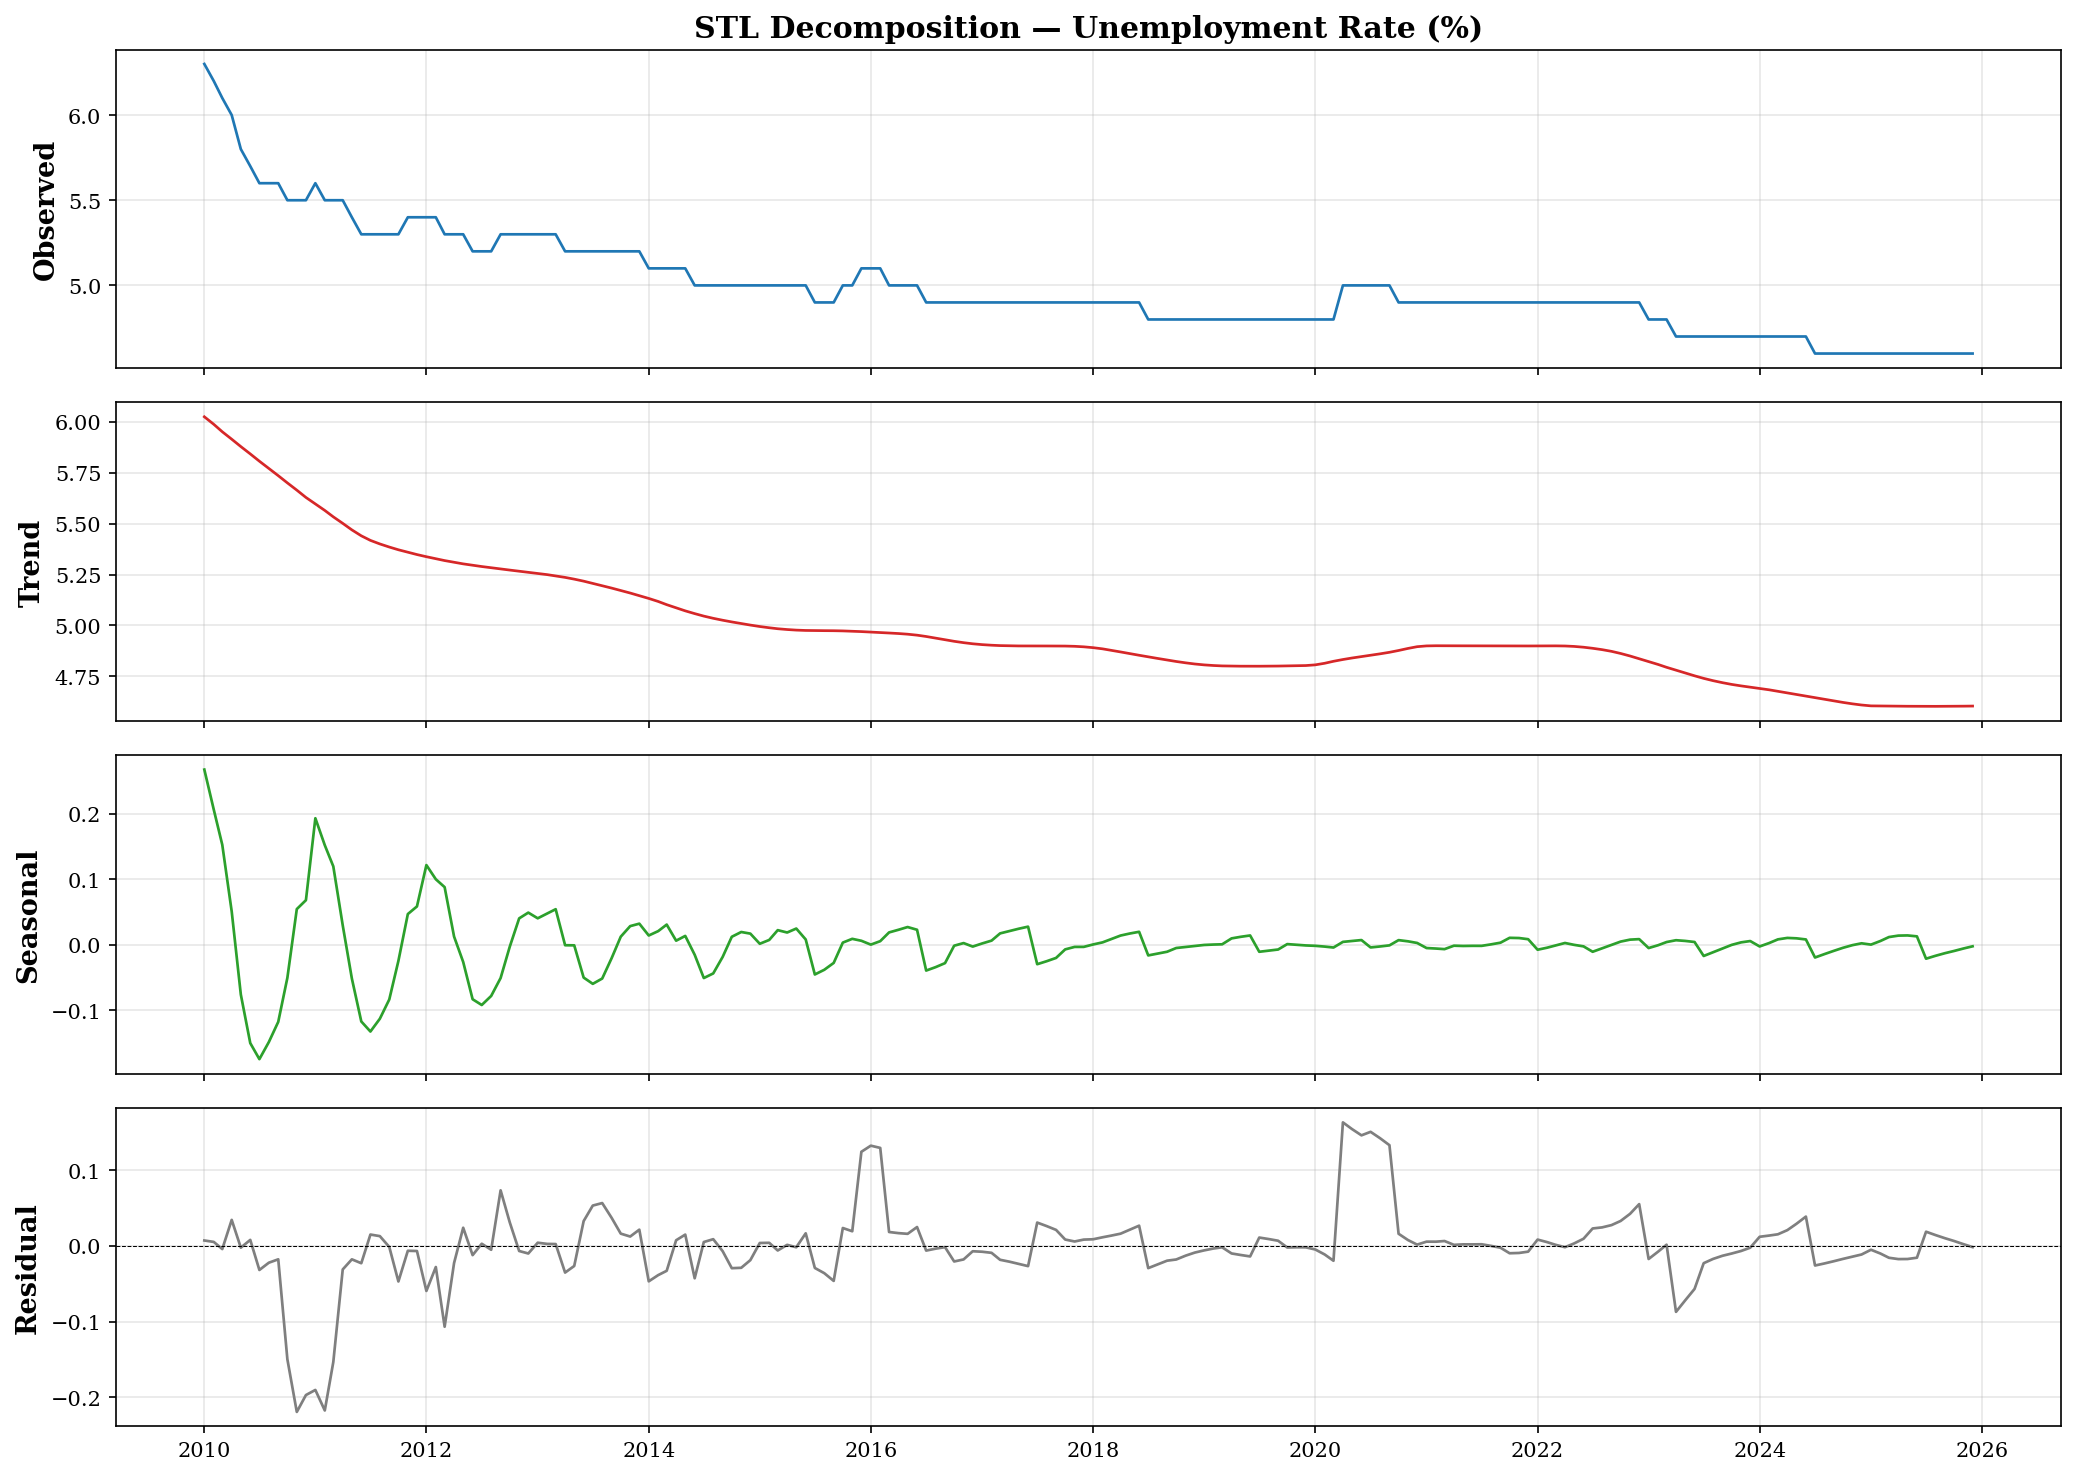

Strength of Trend:       F_T = 0.970
Strength of Seasonality: F_S = 0.337


In [43]:
# ============================================================
# Cell 8: STL Decomposition (Robust to Outliers)
# ============================================================
stl = STL(df['unemployed_rate'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    ('Observed', result.observed, '#1f77b4'),
    ('Trend', result.trend, '#d62728'),
    ('Seasonal', result.seasonal, '#2ca02c'),
    ('Residual', result.resid, '#7f7f7f'),
]
for ax, (name, data, color) in zip(axes, components):
    ax.plot(data, lw=1.3, color=color)
    ax.set_ylabel(name, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, ls='--') if name == 'Residual' else None

axes[0].set_title('STL Decomposition — Unemployment Rate (%)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'eda_stl_decomposition.png')
plt.show()

# Strength of seasonality and trend
var_resid = np.var(result.resid)
F_trend = max(0, 1 - var_resid / np.var(result.trend + result.resid))
F_season = max(0, 1 - var_resid / np.var(result.seasonal + result.resid))
print(f'Strength of Trend:       F_T = {F_trend:.3f}')
print(f'Strength of Seasonality: F_S = {F_season:.3f}')

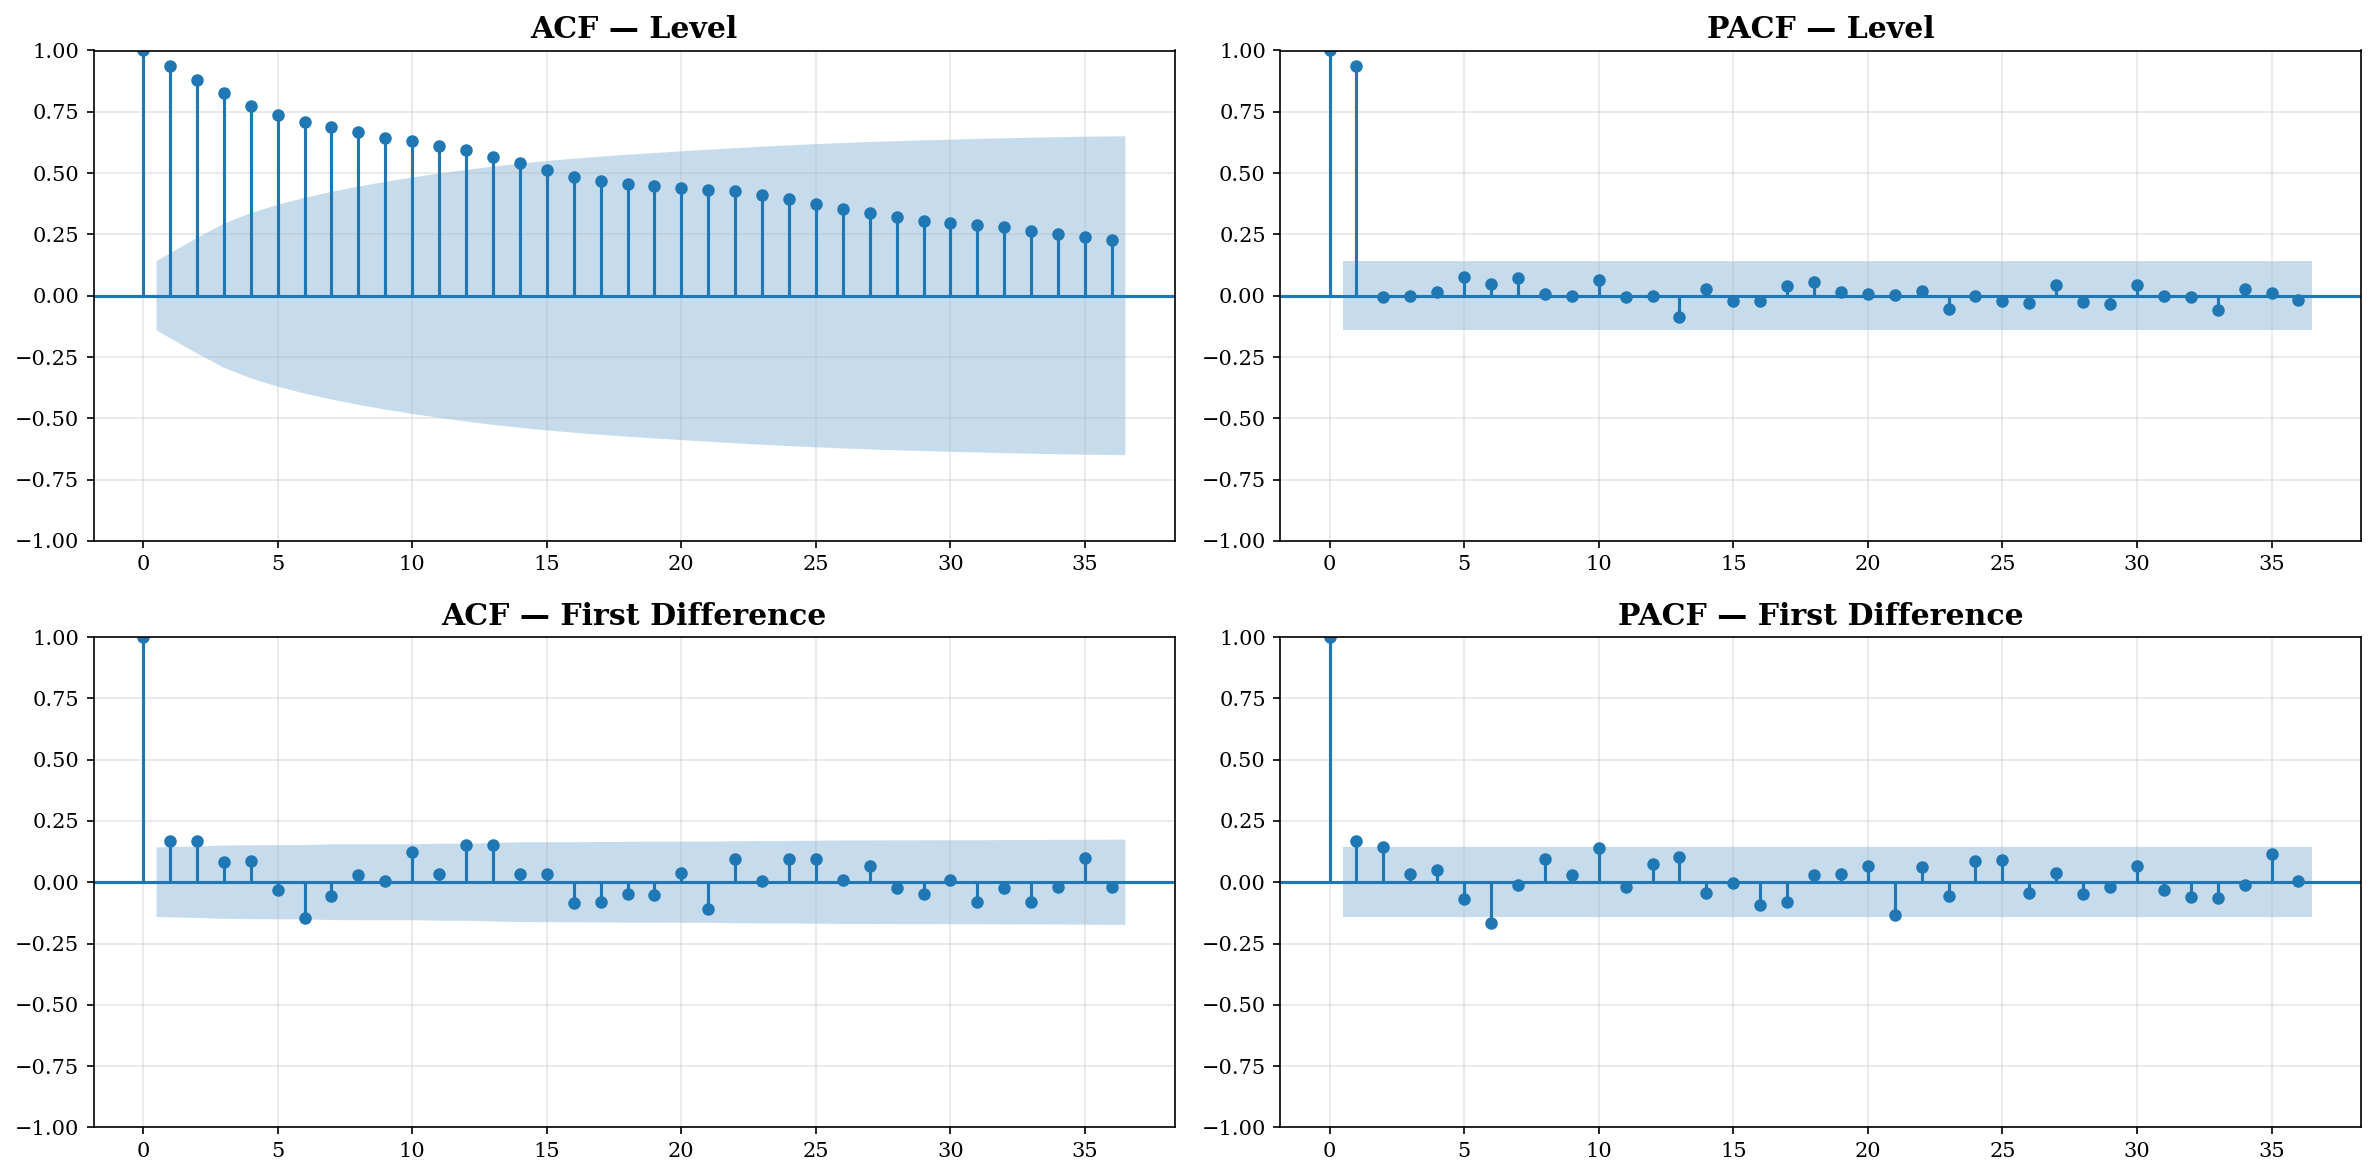

ACF Interpretation:
- Slow decay in level ACF -> non-stationary (confirmed by ADF)
- Significant spike at lag 12 in PACF -> strong annual seasonality
- After differencing: rapid decay -> d=1 is appropriate
- PACF cuts off at lag 2 -> AR(2) component suggested


In [44]:
# ============================================================
# Cell 9: ACF/PACF Analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Level series
plot_acf(df['unemployed_rate'], lags=36, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF — Level', fontweight='bold')
plot_pacf(df['unemployed_rate'], lags=36, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF — Level', fontweight='bold')

# First-differenced series
diff_y = df['unemployed_rate'].diff().dropna()
plot_acf(diff_y, lags=36, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF — First Difference', fontweight='bold')
plot_pacf(diff_y, lags=36, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF — First Difference', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES + 'eda_acf_pacf.png')
plt.show()

print('ACF Interpretation:')
print('- Slow decay in level ACF -> non-stationary (confirmed by ADF)')
print('- Significant spike at lag 12 in PACF -> strong annual seasonality')
print('- After differencing: rapid decay -> d=1 is appropriate')
print('- PACF cuts off at lag 2 -> AR(2) component suggested')

=== IQR Outlier Counts ===
gold_price_usd_avg    13
usd_kzt                0
interest_rate          0
Oil_crude_brent        0
GDP_growth            36
unemployed_rate        6
Base_Rate              0
usd_kzt_volatility    13
rub_kzt               16
dtype: int64


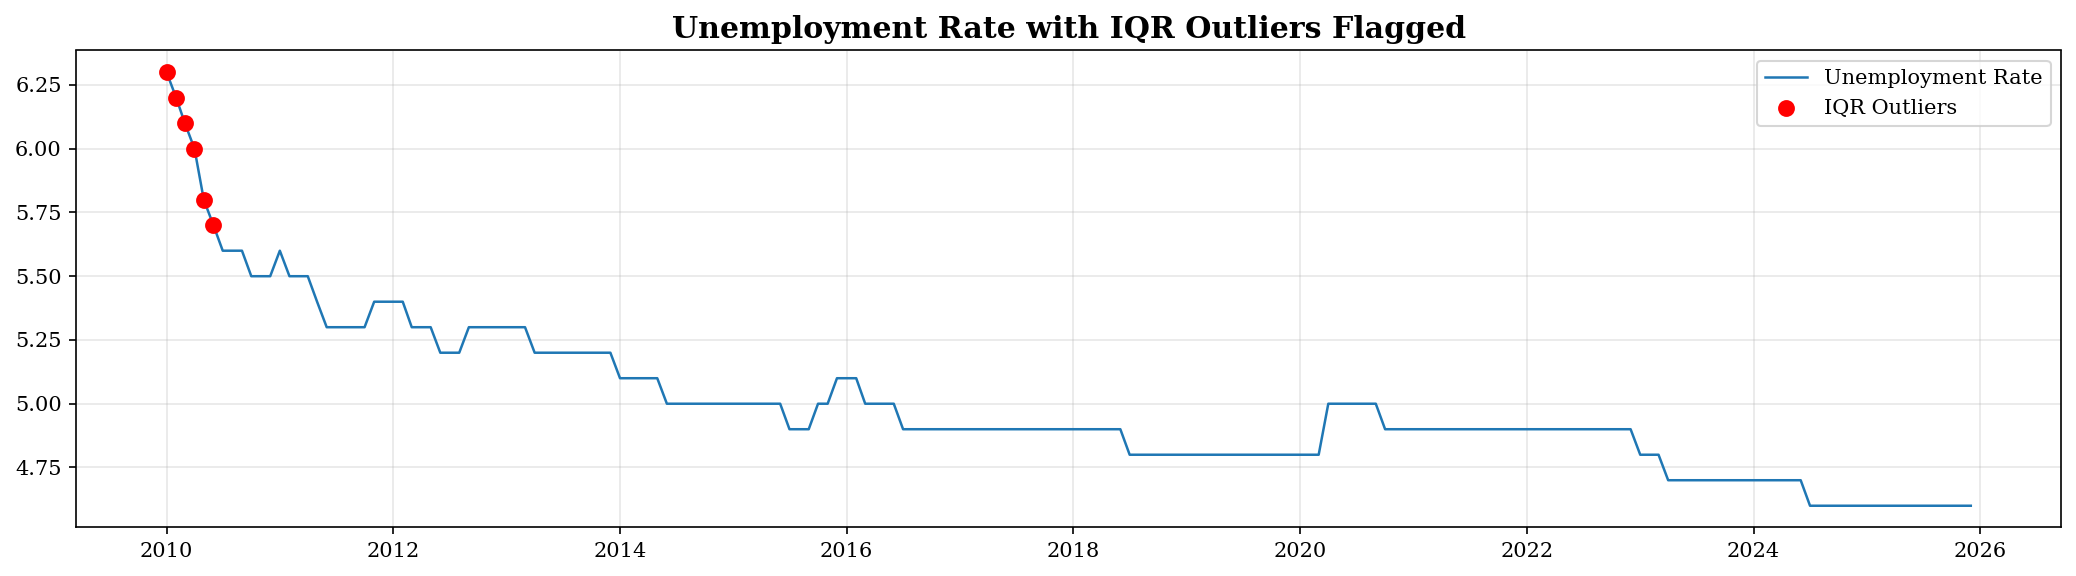

In [45]:
# ============================================================
# Cell 10: Outlier Detection (IQR + Z-score)
# ============================================================
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print('=== IQR Outlier Counts ===')
print(outlier_mask.sum())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['unemployed_rate'], lw=1.2, label='Unemployment Rate')
outlier_dates = df.index[outlier_mask['unemployed_rate']]
ax.scatter(outlier_dates, df.loc[outlier_dates, 'unemployed_rate'],
           color='red', zorder=5, s=50, label='IQR Outliers')
ax.set_title('Unemployment Rate with IQR Outliers Flagged', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES + 'eda_outliers.png')
plt.show()

---
## 3. Advanced Feature Engineering

This section implements all requested feature engineering strategies:
1. **Fourier terms** for complex seasonality
2. **Lagged variables** with Granger causality selection
3. **Rolling statistics** (3m, 6m windows)
4. **Interaction terms** (Oil x USD/KZT shocks)
5. **Calendar dummies** (Q1/Q4, January effect)
6. **Regime indicators** (structural breaks)
7. **PCA on CPI sub-indices**

In [46]:
# ============================================================
# Cell 11: Feature Engineering — Full Pipeline
# ============================================================
df_feat = df.copy()

# ── 3.1 First-Differences for Non-Stationary Regressors ──
diff_cols = ['usd_kzt', 'Oil_crude_brent', 'Base_Rate']
if 'rub_kzt' in df_feat.columns:
    diff_cols.append('rub_kzt')

for col in diff_cols:
    df_feat[f'{col}_diff'] = df_feat[col].diff()

# ── 3.2 Fourier Terms for Seasonality (K=1,2,3) ──
# S_t = sum_{k=1}^{K} [alpha_k * sin(2*pi*k*t/12) + beta_k * cos(2*pi*k*t/12)]
t = np.arange(len(df_feat))
for k in [1, 2, 3]:
    df_feat[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * t / 12)
    df_feat[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * t / 12)
print(f'Added 6 Fourier terms (K=1,2,3)')

# ── 3.3 Lagged Variables ──
for lag in [1, 2, 3, 6, 12]:
    df_feat[f'y_lag{lag}'] = df_feat['unemployed_rate'].shift(lag)
print(f'Added lags: 1, 2, 3, 6, 12')

# ── 3.4 Rolling Statistics (Oil, USD/KZT) ──
for col in ['Oil_crude_brent', 'usd_kzt']:
    for window in [3, 6]:
        df_feat[f'{col}_roll_mean_{window}m'] = df_feat[col].rolling(window).mean()
        df_feat[f'{col}_roll_std_{window}m'] = df_feat[col].rolling(window).std()
print(f'Added 8 rolling statistics (3m, 6m for Oil & USD/KZT)')

# ── 3.5 Interaction Terms ──
# Delta_Oil x Delta_USD/KZT: captures joint commodity-currency shocks
df_feat['oil_x_usdkzt_shock'] = df_feat['Oil_crude_brent_diff'] * df_feat['usd_kzt_diff']
print(f'Added interaction: Delta_Oil x Delta_USD/KZT')

# ── 3.6 Calendar Dummies ──
df_feat['is_january'] = (df_feat.index.month == 1).astype(int)
df_feat['is_Q1'] = (df_feat.index.quarter == 1).astype(int)
df_feat['is_Q4'] = (df_feat.index.quarter == 4).astype(int)
print(f'Added 3 calendar dummies: January, Q1, Q4')

# ── 3.7 Regime Indicators (Structural Breaks) ──
df_feat['regime_tenge_float'] = (
    (df_feat.index >= '2015-08-01') & (df_feat.index <= '2016-03-01')
).astype(int)
df_feat['regime_covid'] = (
    (df_feat.index >= '2020-03-01') & (df_feat.index <= '2020-12-01')
).astype(int)
df_feat['regime_jan_events'] = (
    (df_feat.index >= '2022-01-01') & (df_feat.index <= '2022-06-01')
).astype(int)
print(f'Added 3 regime dummies: Tenge float (2015), COVID (2020), January events (2022)')

# ── 3.8 PCA on CPI Sub-Indices ──
cpi_aligned = cpi_df.loc[df_feat.index]
cpi_scaler = StandardScaler()
cpi_scaled = cpi_scaler.fit_transform(cpi_aligned)

pca = PCA(n_components=3, random_state=42)
cpi_pcs = pca.fit_transform(cpi_scaled)

for i in range(3):
    df_feat[f'CPI_PC{i+1}'] = cpi_pcs[:, i]

print(f'\nPCA on {len(cpi_cols)} CPI sub-indices:')
print(f'  Explained variance ratios: {pca.explained_variance_ratio_.round(3)}')
print(f'  Cumulative: {pca.explained_variance_ratio_.cumsum().round(3)}')

# Drop raw level columns (keep diffs)
df_feat.drop(columns=diff_cols + ['usd_kzt_daily'] * ('usd_kzt_daily' in df_feat.columns),
             inplace=True, errors='ignore')

# Drop NaN rows from lagging/rolling/differencing
df_feat.dropna(inplace=True)

print(f'\nFinal feature matrix: {df_feat.shape}')
print(f'Date range: {df_feat.index.min().date()} -> {df_feat.index.max().date()}')
print(f'\nAll features ({len([c for c in df_feat.columns if c != "unemployed_rate"])}): ')
for i, c in enumerate([c for c in df_feat.columns if c != 'unemployed_rate']):
    print(f'  {i+1:2d}. {c}')

Added 6 Fourier terms (K=1,2,3)
Added lags: 1, 2, 3, 6, 12
Added 8 rolling statistics (3m, 6m for Oil & USD/KZT)
Added interaction: Delta_Oil x Delta_USD/KZT
Added 3 calendar dummies: January, Q1, Q4
Added 3 regime dummies: Tenge float (2015), COVID (2020), January events (2022)

PCA on 13 CPI sub-indices:
  Explained variance ratios: [0.563 0.144 0.094]
  Cumulative: [0.563 0.707 0.801]

Final feature matrix: (180, 38)
Date range: 2011-01-01 -> 2025-12-01

All features (37): 
   1. gold_price_usd_avg
   2. interest_rate
   3. GDP_growth
   4. usd_kzt_volatility
   5. usd_kzt_diff
   6. Oil_crude_brent_diff
   7. Base_Rate_diff
   8. rub_kzt_diff
   9. fourier_sin_1
  10. fourier_cos_1
  11. fourier_sin_2
  12. fourier_cos_2
  13. fourier_sin_3
  14. fourier_cos_3
  15. y_lag1
  16. y_lag2
  17. y_lag3
  18. y_lag6
  19. y_lag12
  20. Oil_crude_brent_roll_mean_3m
  21. Oil_crude_brent_roll_std_3m
  22. Oil_crude_brent_roll_mean_6m
  23. Oil_crude_brent_roll_std_6m
  24. usd_kzt_roll_me

In [47]:
# ============================================================
# Cell 12: Granger Causality Tests for Lag Selection
# ============================================================
granger_results = []
target = df['unemployed_rate'].dropna()

test_vars = ['Oil_crude_brent', 'usd_kzt', 'GDP_growth',
             'interest_rate', 'Base_Rate', 'gold_price_usd_avg']
if 'rub_kzt' in df.columns:
    test_vars.append('rub_kzt')

for var in test_vars:
    series = df[var].dropna()
    combined = pd.concat([target, series], axis=1).dropna()
    try:
        gc = grangercausalitytests(combined, maxlag=6, verbose=False)
        for lag in [1, 2, 3, 6]:
            if lag in gc:
                f_pval = gc[lag][0]['ssr_ftest'][1]
                granger_results.append({
                    'Variable': var,
                    'Lag': lag,
                    'F-test p-value': round(f_pval, 4),
                    'Significant': 'Yes' if f_pval < 0.05 else 'No',
                })
    except Exception as e:
        print(f'Granger test failed for {var}: {e}')

gc_df = pd.DataFrame(granger_results)
print('=== Granger Causality Tests (X -> Unemployment) ===')
display(gc_df.pivot_table(index='Variable', columns='Lag',
                          values='F-test p-value').round(4)
        .style.applymap(lambda v: 'background-color: #d4edda' if v < 0.05
                        else 'background-color: #f8d7da'))
print('\nGreen = significant at 5% level (include this lag)')

=== Granger Causality Tests (X -> Unemployment) ===


Lag,1,2,3,6
Variable,,,,
Base_Rate,0.061200,0.016800,0.054300,0.134300
GDP_growth,0.250400,0.600400,0.765600,0.003600
Oil_crude_brent,0.786000,0.929700,0.825000,0.448500
gold_price_usd_avg,0.106900,0.192400,0.402100,0.770800
interest_rate,0.019400,0.001000,0.001600,0.009900
rub_kzt,0.522900,0.022700,0.050800,0.039600
usd_kzt,0.000800,0.000300,0.001500,0.103700



Green = significant at 5% level (include this lag)


---
## 4. Train/Test Split & Utility Functions

In [48]:
# ============================================================
# Cell 13: Train/Test Split
# ============================================================
SPLIT_DATE = '2023-12-01'

y = df_feat['unemployed_rate']
X = df_feat.drop(columns=['unemployed_rate'])

y_train, y_test = y.loc[:SPLIT_DATE], y.loc['2024-01-01':]
X_train, X_test = X.loc[:SPLIT_DATE], X.loc['2024-01-01':]

forecasts = {}
results_list = []

def evaluate(name, actual, predicted, train_y=y_train):
    """Compute MAE, RMSE, MAPE, MASE, R2."""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    r2 = r2_score(actual, predicted)
    naive_mae = np.mean(np.abs(np.diff(train_y)))
    mase = mae / naive_mae if naive_mae > 0 else np.nan
    print(f'[{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  '
          f'MAPE={mape:.2f}%  R2={r2:.4f}  MASE={mase:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse,
            'MAPE': mape, 'R2': r2, 'MASE': mase}

print(f'Train: {y_train.index.min().date()} -> {y_train.index.max().date()} | n={len(y_train)}')
print(f'Test:  {y_test.index.min().date()} -> {y_test.index.max().date()} | n={len(y_test)}')
print(f'Features: {X_train.shape[1]}')

Train: 2011-01-01 -> 2023-12-01 | n=156
Test:  2024-01-01 -> 2025-12-01 | n=24
Features: 37


---
## 5. Model Building — Hybrid Stack

| # | Model | Type | Key Property |
|---|-------|------|--------------|
| 1 | SARIMA | Classical | Univariate baseline, captures AR + seasonal |
| 2 | SARIMAX | Classical | SARIMA + exogenous macro shocks |
| 3 | VAR | Classical | Multivariate system dynamics |
| 4 | ARDL | Econometric | Distributed lag structure, Granger-informed |
| 5 | XGBoost | ML (Tree) | Non-linear, handles interactions, regime shifts |
| 6 | Prophet | ML (Additive) | Robust to outliers, holiday/regime effects built-in |
| 7 | Random Forest | ML (Ensemble) | Feature importance, low variance |
| 8 | Elastic Net | ML (Linear) | Sparse regularization, multicollinearity-robust |
| 9 | ANN (MLP) | Deep Learning | Universal approximator |
| 10 | LSTM | Deep Learning | Sequential memory, long-range dependencies |

### Model 1 — SARIMA$(2,1,1)(1,1,1)_{12}$ (Univariate Baseline)

In [49]:
# ============================================================
# Cell 14: Model 1 — SARIMA
# ============================================================
sarima = SARIMAX(y_train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
print(sarima_fit.summary().tables[1])

sarima_pred = sarima_fit.forecast(steps=len(y_test))
sarima_pred.index = y_test.index
forecasts['SARIMA'] = sarima_pred
results_list.append(evaluate('SARIMA', y_test, sarima_pred))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7862      0.378      2.079      0.038       0.045       1.527
ar.L2      -6.383e-05      0.000     -0.207      0.836      -0.001       0.001
ma.L1         -1.1941      0.493     -2.420      0.016      -2.161      -0.227
ar.S.L12   -6.328e-05   5.91e-05     -1.070      0.284      -0.000    5.26e-05
ma.S.L12      -0.8502      0.097     -8.799      0.000      -1.040      -0.661
sigma2         0.0010      0.001      1.217      0.224      -0.001       0.003
[SARIMA]  MAE=0.0256  RMSE=0.0302  MAPE=0.55%  R2=0.5128  MASE=1.8871


### Model 2 — SARIMAX$(2,1,1)(1,1,1)_{12}$ + Exogenous

In [50]:
# ============================================================
# Cell 15: Model 2 — SARIMAX
# ============================================================
exog_cols = [c for c in X_train.columns if c.endswith('_diff')]
sarimax = SARIMAX(y_train, exog=X_train[exog_cols],
                  order=(2, 1, 1), seasonal_order=(1, 1, 1, 12),
                  enforce_stationarity=False, enforce_invertibility=False)
sarimax_fit = sarimax.fit(disp=False, maxiter=500)

sarimax_pred = sarimax_fit.forecast(steps=len(y_test), exog=X_test[exog_cols])
sarimax_pred.index = y_test.index
forecasts['SARIMAX'] = sarimax_pred
results_list.append(evaluate('SARIMAX', y_test, sarimax_pred))

[SARIMAX]  MAE=0.0249  RMSE=0.0291  MAPE=0.54%  R2=0.5488  MASE=1.8361


### Model 3 — VAR (Vector Autoregression)

In [ ]:
# # ============================================================
# # Cell 16: Model 3 — VAR
# # ============================================================
# # VAR requires all series to be stationary
# var_cols = ['unemployed_rate'] + exog_cols
# var_data_train = df_feat[var_cols].loc[:SPLIT_DATE].dropna()
# var_data_test = df_feat[var_cols].loc['2024-01-01':].dropna()

# var_model = VAR(var_data_train)

# # Select optimal lag order via AIC
# lag_order = var_model.select_order(maxlags=12)
# print('VAR Lag Order Selection:')
# print(lag_order.summary())

# optimal_lag = lag_order.aic
# var_fit = var_model.fit(optimal_lag)
# print(f'\nSelected lag: {optimal_lag}')

# # Forecast
# var_fc = var_fit.forecast(var_data_train.values[-optimal_lag:], steps=len(y_test))
# var_pred = pd.Series(var_fc[:, 0], index=y_test.index)  # first col = unemployed_rate
# forecasts['VAR'] = var_pred
# results_list.append(evaluate('VAR', y_test, var_pred))

VAR Lag Order Selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        6.053       6.156       425.3       6.095
1        2.652      3.271*       14.19       2.904
2       2.237*       3.372      9.381*      2.698*
3        2.333       3.983       10.36       3.004
4        2.296       4.462       10.04       3.176
5        2.412       5.093       11.38       3.502
6        2.414       5.611       11.57       3.713
7        2.499       6.212       12.85       4.008
8        2.527       6.755       13.58       4.245
9        2.623       7.367       15.47       4.551
10       2.765       8.024       18.63       4.902
11       2.890       8.664       22.33       5.236
12       3.052       9.342       28.11       5.607
--------------------------------------------------

Selected lag: 2
[VAR]  MAE=0.1204  RMSE=0.1362  MAPE=2.62%  R2=-8.8940  MASE=8.8891


### Model 4 — ARDL (Autoregressive Distributed Lag)

In [ ]:
# ============================================================
# Cell 17: Model 4 — ARDL (Fixed with ElasticNet Selection)
# ============================================================
# 1. Ensure ElasticNet has run, and extract its chosen features
# (This assumes coef_df was created in the Elastic Net cell)
selected_features = coef_df[coef_df != 0].index.tolist()
print(f"ARDL using {len(selected_features)} features selected by Elastic Net.")

# 2. Filter the train and test sets to ONLY include these features
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

# 3. Add constant for OLS
X_ardl_train = sm.add_constant(X_train_reduced, has_constant='add')
X_ardl_test = sm.add_constant(X_test_reduced, has_constant='add')

# 4. Fit ARDL using robust standard errors (HC1)
ardl = sm.OLS(y_train, X_ardl_train).fit(cov_type='HC1')
print(f'ARDL R2 (in-sample): {ardl.rsquared:.4f}')
print(f'ARDL Adj-R2: {ardl.rsquared_adj:.4f}')

# Check for autocorrelation in residuals (Target ~2.0)
dw_stat = sm.stats.stattools.durbin_watson(ardl.resid)
print(f'Durbin-Watson: {dw_stat:.3f}')

# 5. Predict and Evaluate
ardl_pred = ardl.predict(X_ardl_test)
forecasts['ARDL'] = ardl_pred
results_list.append(evaluate('ARDL', y_test, ardl_pred))

ARDL R2 (in-sample): 0.9754
ARDL Adj-R2: 0.9678
Durbin-Watson: 2.041
[ARDL]  MAE=0.0959  RMSE=0.1082  MAPE=2.08%  R2=-5.2435  MASE=7.0748


### Model 5 — XGBoost

[XGBoost]  MAE=0.1132  RMSE=0.1283  MAPE=2.46%  R2=-7.7759  MASE=8.3536


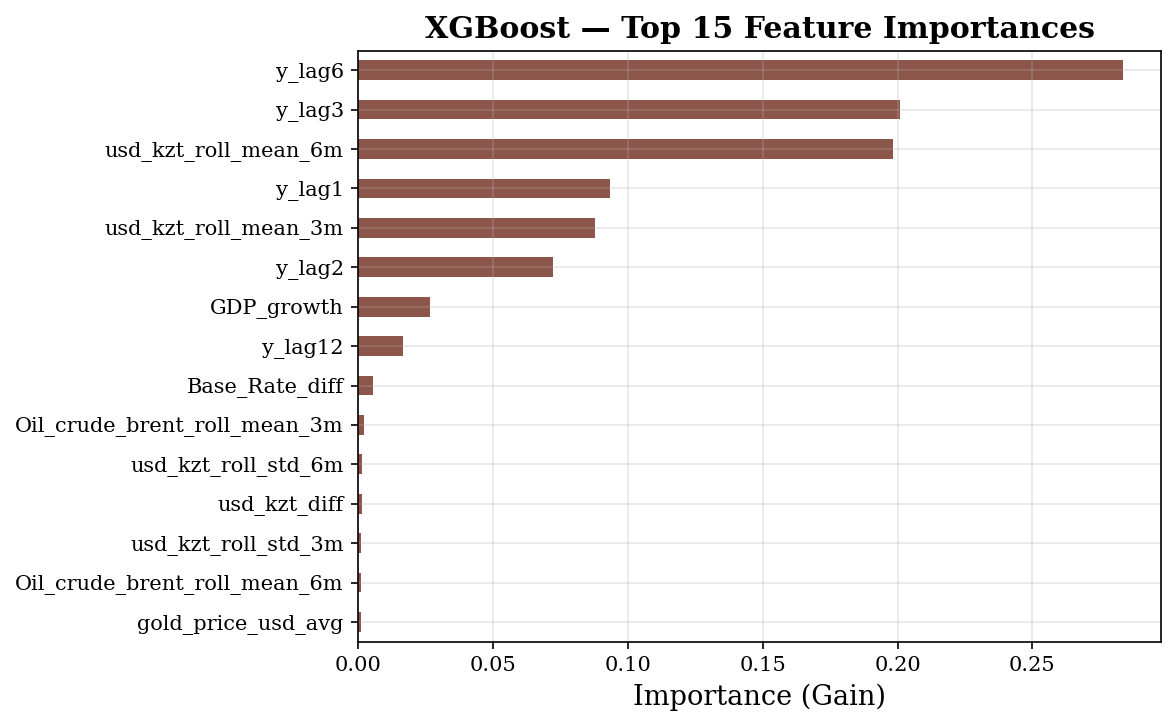

In [ ]:
# ============================================================
# Cell 18: Model 5 — XGBoost
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,    # L1
    reg_lambda=1.0,   # L2
    random_state=42,
    early_stopping_rounds=50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=0
)

xgb_pred = pd.Series(xgb_model.predict(X_test), index=y_test.index)
forecasts['XGBoost'] = xgb_pred
results_list.append(evaluate('XGBoost', y_test, xgb_pred))

# Feature importance
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_n = importance.nlargest(15)
fig, ax = plt.subplots(figsize=(8, 5))
top_n.sort_values().plot.barh(ax=ax, color='#8c564b')
ax.set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig(FIGURES + 'model_xgb_importance.png')
plt.show()

### Model 6 — Prophet

In [ ]:
# # ============================================================
# # Cell 19: Model 6 — Prophet
# # ============================================================
# prophet_train = pd.DataFrame({
#     'ds': y_train.index,
#     'y': y_train.values,
# })

# # Add regressors
# prophet_regressors = ['Oil_crude_brent_diff', 'usd_kzt_diff', 'GDP_growth']
# for reg in prophet_regressors:
#     if reg in X_train.columns:
#         prophet_train[reg] = X_train[reg].values

# m = Prophet(
#     yearly_seasonality=True,
#     weekly_seasonality=False,
#     daily_seasonality=False,
#     changepoint_prior_scale=0.05,
#     seasonality_mode='multiplicative',
# )

# for reg in prophet_regressors:
#     if reg in prophet_train.columns:
#         m.add_regressor(reg)

# m.fit(prophet_train)

# # Predict
# prophet_test = pd.DataFrame({'ds': y_test.index})
# for reg in prophet_regressors:
#     if reg in X_test.columns:
#         prophet_test[reg] = X_test[reg].values

# prophet_fc = m.predict(prophet_test)
# prophet_pred = pd.Series(prophet_fc['yhat'].values, index=y_test.index)
# forecasts['Prophet'] = prophet_pred
# results_list.append(evaluate('Prophet', y_test, prophet_pred))

04:13:35 - cmdstanpy - INFO - Chain [1] start processing
04:13:36 - cmdstanpy - INFO - Chain [1] done processing


[Prophet]  MAE=0.0351  RMSE=0.0441  MAPE=0.76%  R2=-0.0364  MASE=2.5937


### Model 7 — Random Forest

In [ ]:
# # ============================================================
# # Cell 20: Model 7 — Random Forest
# # ============================================================
# rf = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=6,
#     min_samples_leaf=5,
#     max_features='sqrt',
#     random_state=42,
#     n_jobs=-1,
# )
# rf.fit(X_train, y_train)

# rf_pred = pd.Series(rf.predict(X_test), index=y_test.index)
# forecasts['RF'] = rf_pred
# results_list.append(evaluate('RF', y_test, rf_pred))

[RF]  MAE=0.1278  RMSE=0.1379  MAPE=2.77%  R2=-9.1425  MASE=9.4306


### Model 8 — Elastic Net

In [56]:
# ============================================================
# Cell 21: Model 8 — Elastic Net
# ============================================================
scaler_en = StandardScaler()
X_train_sc = scaler_en.fit_transform(X_train)
X_test_sc = scaler_en.transform(X_test)

enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95],
                    alphas=np.logspace(-4, 1, 50),
                    cv=5, random_state=42, max_iter=10000)
enet.fit(X_train_sc, y_train)
print(f'Elastic Net: alpha={enet.alpha_:.4f}, l1_ratio={enet.l1_ratio_:.2f}')

enet_pred = pd.Series(enet.predict(X_test_sc), index=y_test.index)
forecasts['ElasticNet'] = enet_pred
results_list.append(evaluate('ElasticNet', y_test, enet_pred))

# Non-zero coefficients
coef_df = pd.Series(enet.coef_, index=X_train.columns)
print(f'\nNon-zero coefficients: {(coef_df != 0).sum()} / {len(coef_df)}')
print(coef_df[coef_df != 0].sort_values(ascending=False).round(4))

Elastic Net: alpha=0.0034, l1_ratio=0.95
[ElasticNet]  MAE=0.0211  RMSE=0.0300  MAPE=0.46%  R2=0.5202  MASE=1.5537

Non-zero coefficients: 13 / 37
y_lag1                         0.1731
y_lag12                        0.0141
usd_kzt_roll_std_3m            0.0062
regime_covid                   0.0020
Oil_crude_brent_roll_std_6m    0.0015
CPI_PC2                        0.0014
is_Q4                          0.0013
fourier_cos_1                  0.0006
y_lag6                         0.0005
fourier_sin_3                 -0.0003
fourier_sin_1                 -0.0013
CPI_PC1                       -0.0029
usd_kzt_roll_mean_6m          -0.0063
dtype: float64


### Model 9 — ANN (Multi-Layer Perceptron)

In [ ]:
# # ============================================================
# # Cell 22: Model 9 — ANN (MLP)
# # ============================================================
# scaler_ann = StandardScaler()
# X_train_ann = scaler_ann.fit_transform(X_train)
# X_test_ann = scaler_ann.transform(X_test)

# ann = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation='relu',
#     solver='adam',
#     alpha=0.001,
#     learning_rate='adaptive',
#     learning_rate_init=0.001,
#     max_iter=1000,
#     early_stopping=True,
#     validation_fraction=0.15,
#     n_iter_no_change=30,
#     random_state=42,
# )
# ann.fit(X_train_ann, y_train)

# ann_pred = pd.Series(ann.predict(X_test_ann), index=y_test.index)
# forecasts['ANN'] = ann_pred
# results_list.append(evaluate('ANN', y_test, ann_pred))

[ANN]  MAE=1.6998  RMSE=2.0283  MAPE=36.91%  R2=-2193.2390  MASE=125.4586


### Model 10 — LSTM (Long Short-Term Memory)

LSTM — train: (144, 12, 37)  test: (24, 12, 37)
[LSTM]  MAE=0.1302  RMSE=0.1347  MAPE=2.82%  R2=-8.6803  MASE=9.6114


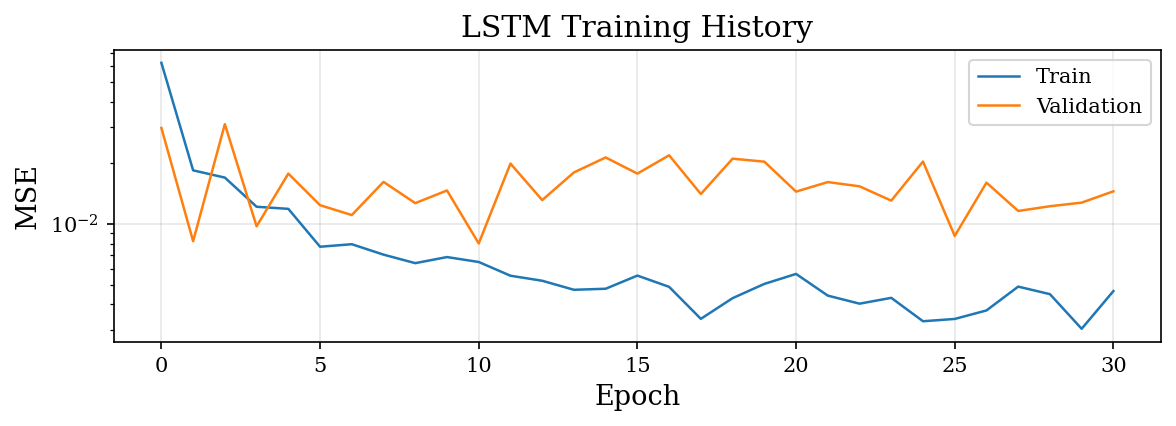

In [58]:
# ============================================================
# Cell 23: Model 10 — LSTM
# ============================================================
LOOKBACK = 12

sc_X = MinMaxScaler()
sc_y = MinMaxScaler()

feat_cols = [c for c in df_feat.columns if c != 'unemployed_rate']
X_all_sc = sc_X.fit_transform(df_feat[feat_cols])
y_all_sc = sc_y.fit_transform(df_feat[['unemployed_rate']])

X_seq, y_seq, dates_seq = [], [], []
for i in range(LOOKBACK, len(X_all_sc)):
    X_seq.append(X_all_sc[i - LOOKBACK:i])
    y_seq.append(y_all_sc[i, 0])
    dates_seq.append(df_feat.index[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
dates_seq = pd.DatetimeIndex(dates_seq)

tr_mask = dates_seq <= pd.Timestamp(SPLIT_DATE)
te_mask = dates_seq >= pd.Timestamp('2024-01-01')
X_tr, y_tr = X_seq[tr_mask], y_seq[tr_mask]
X_te, y_te = X_seq[te_mask], y_seq[te_mask]
print(f'LSTM — train: {X_tr.shape}  test: {X_te.shape}')

tf.random.set_seed(42)
lstm_model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, X_tr.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')

history = lstm_model.fit(
    X_tr, y_tr, epochs=200, batch_size=16,
    validation_split=0.15,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=0
)

lstm_pred_sc = lstm_model.predict(X_te, verbose=0)
lstm_pred_vals = sc_y.inverse_transform(lstm_pred_sc).flatten()
lstm_pred = pd.Series(lstm_pred_vals, index=dates_seq[te_mask])
forecasts['LSTM'] = lstm_pred

# Align test index
common_idx = y_test.index.intersection(lstm_pred.index)
results_list.append(evaluate('LSTM', y_test.loc[common_idx], lstm_pred.loc[common_idx]))

# Training history
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'], label='Train', lw=1.2)
ax.plot(history.history['val_loss'], label='Validation', lw=1.2)
ax.set(xlabel='Epoch', ylabel='MSE', title='LSTM Training History')
ax.legend(); ax.set_yscale('log')
plt.tight_layout()
plt.savefig(FIGURES + 'model_lstm_training.png')
plt.show()

---
## 5. Walk-Forward Cross-Validation

Standard $k$-fold CV violates temporal ordering. Instead we use **expanding-window walk-forward validation**:

```
Fold 1: Train [2011..2019] -> Test [2020]
Fold 2: Train [2011..2020] -> Test [2021]
Fold 3: Train [2011..2021] -> Test [2022]
Fold 4: Train [2011..2022] -> Test [2023]
```

This prevents data leakage and tests temporal generalization.

In [59]:
# ============================================================
# Cell 24: Walk-Forward Cross-Validation
# ============================================================
from sklearn.base import clone

def walk_forward_cv(model_fn, X_full, y_full, initial_train_end='2019-12-01',
                    step_months=12, n_folds=4):
    """
    Expanding-window walk-forward cross-validation.
    
    Parameters
    ----------
    model_fn : callable
        Function that returns a fitted model: model_fn(X_train, y_train) -> model with .predict()
    X_full, y_full : pd.DataFrame, pd.Series
        Full feature matrix and target (pre-split date)
    initial_train_end : str
        End date of initial training window
    step_months : int
        Months to advance the test window each fold
    n_folds : int
        Number of walk-forward folds
    
    Returns
    -------
    dict with fold-level and aggregated metrics
    """
    fold_results = []
    all_actuals, all_preds = [], []
    
    train_end = pd.Timestamp(initial_train_end)
    
    for fold in range(n_folds):
        test_start = train_end + pd.DateOffset(months=1)
        test_end = test_start + pd.DateOffset(months=step_months - 1)
        
        # Subset
        X_tr = X_full.loc[:train_end]
        y_tr = y_full.loc[:train_end]
        X_te = X_full.loc[test_start:test_end]
        y_te = y_full.loc[test_start:test_end]
        
        if len(X_te) == 0:
            break
        
        # Fit and predict
        model = model_fn(X_tr, y_tr)
        preds = model.predict(X_te)
        
        mae = mean_absolute_error(y_te, preds)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        
        fold_results.append({
            'Fold': fold + 1,
            'Train': f'{X_tr.index.min().date()} - {train_end.date()}',
            'Test': f'{test_start.date()} - {X_te.index.max().date()}',
            'n_test': len(X_te),
            'MAE': mae,
            'RMSE': rmse,
        })
        
        all_actuals.extend(y_te.values)
        all_preds.extend(preds)
        
        # Expand window
        train_end = test_end
    
    # Aggregate
    agg_mae = mean_absolute_error(all_actuals, all_preds)
    agg_rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
    
    return {
        'folds': pd.DataFrame(fold_results),
        'agg_MAE': agg_mae,
        'agg_RMSE': agg_rmse,
    }

# Pre-test data for CV
X_cv = X.loc[:SPLIT_DATE]
y_cv = y.loc[:SPLIT_DATE]

# Walk-forward CV for key models
wf_results = {}

# Ridge
def ridge_fn(Xtr, ytr):
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    m = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(Xtr_sc, ytr)
    class Wrapper:
        def predict(self, X): return m.predict(sc.transform(X))
    return Wrapper()

# XGBoost
def xgb_fn(Xtr, ytr):
    m = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, random_state=42)
    m.fit(Xtr, ytr, verbose=0)
    return m

# Random Forest
def rf_fn(Xtr, ytr):
    m = RandomForestRegressor(n_estimators=300, max_depth=6,
                              min_samples_leaf=5, random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr)
    return m

print('=== Walk-Forward Cross-Validation ===')
for name, fn in [('Ridge', ridge_fn), ('XGBoost', xgb_fn), ('RF', rf_fn)]:
    wf = walk_forward_cv(fn, X_cv, y_cv)
    wf_results[name] = wf
    print(f'\n{name}: Aggregate MAE={wf["agg_MAE"]:.4f}, RMSE={wf["agg_RMSE"]:.4f}')
    display(wf['folds'])

=== Walk-Forward Cross-Validation ===

Ridge: Aggregate MAE=0.0656, RMSE=0.0878


,Fold,Train,Test,n_test,MAE,RMSE
0,1,2011-01-01 - 2019-12-01,2020-01-01 - 2020-12-01,12,0.092201,0.113189
1,2,2011-01-01 - 2020-12-01,2021-01-01 - 2021-12-01,12,0.020963,0.024389
2,3,2011-01-01 - 2021-12-01,2022-01-01 - 2022-12-01,12,0.027124,0.038020
3,4,2011-01-01 - 2022-12-01,2023-01-01 - 2023-12-01,12,0.122186,0.126538



XGBoost: Aggregate MAE=0.0904, RMSE=0.1321


,Fold,Train,Test,n_test,MAE,RMSE
0,1,2011-01-01 - 2019-12-01,2020-01-01 - 2020-12-01,12,0.043453,0.061445
1,2,2011-01-01 - 2020-12-01,2021-01-01 - 2021-12-01,12,0.041807,0.044090
2,3,2011-01-01 - 2021-12-01,2022-01-01 - 2022-12-01,12,0.031494,0.042040
3,4,2011-01-01 - 2022-12-01,2023-01-01 - 2023-12-01,12,0.244957,0.249668



RF: Aggregate MAE=0.0513, RMSE=0.0857


,Fold,Train,Test,n_test,MAE,RMSE
0,1,2011-01-01 - 2019-12-01,2020-01-01 - 2020-12-01,12,0.036918,0.062693
1,2,2011-01-01 - 2020-12-01,2021-01-01 - 2021-12-01,12,0.011812,0.015653
2,3,2011-01-01 - 2021-12-01,2022-01-01 - 2022-12-01,12,0.001391,0.001960
3,4,2011-01-01 - 2022-12-01,2023-01-01 - 2023-12-01,12,0.155041,0.158714


---
## 6. Model Comparison & Defense-Ready Visualizations

In [60]:
# ============================================================
# Cell 25: Model Comparison Table
# ============================================================
results_df = pd.DataFrame(results_list).set_index('Model').sort_values('MAE')

print('\n' + '='*70)
print('MODEL COMPARISON — Out-of-Sample Performance (2024-01 to 2025-12)')
print('='*70)
display(results_df.round(4).style
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE', 'MASE'], color='#d4edda')
    .highlight_max(subset=['R2'], color='#d4edda')
    .format(precision=4))


MODEL COMPARISON — Out-of-Sample Performance (2024-01 to 2025-12)


,MAE,RMSE,MAPE,R2,MASE
Model,,,,,
ElasticNet,0.0211,0.0300,0.4568,0.5202,1.5537
SARIMAX,0.0249,0.0291,0.5375,0.5488,1.8361
SARIMA,0.0256,0.0302,0.5528,0.5128,1.8871
Prophet,0.0351,0.0441,0.7615,-0.0364,2.5937
ARDL,0.0959,0.1082,2.0815,-5.2435,7.0748
XGBoost,0.1132,0.1283,2.4581,-7.7759,8.3536
VAR,0.1204,0.1362,2.6166,-8.8940,8.8891
RF,0.1278,0.1379,2.7731,-9.1425,9.4306
LSTM,0.1302,0.1347,2.8211,-8.6803,9.6114


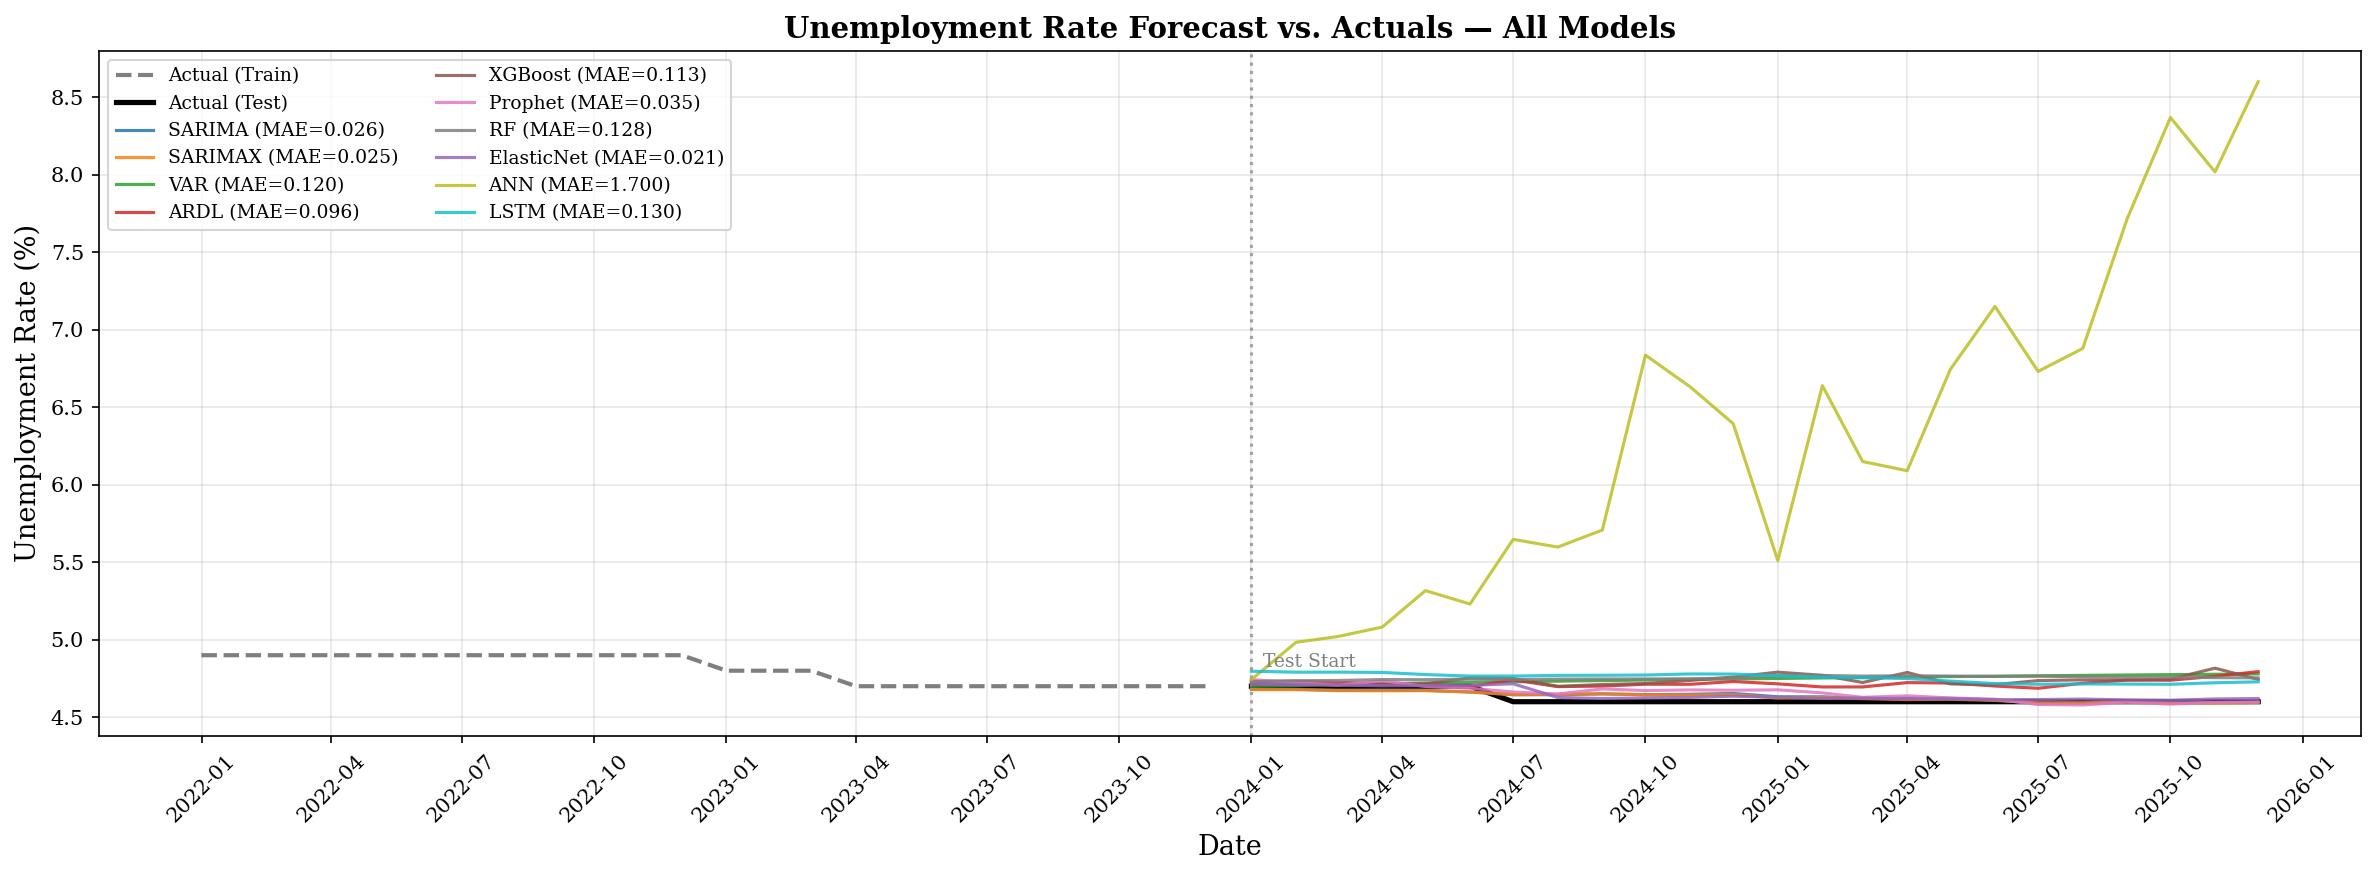

In [61]:
# ============================================================
# Cell 26: Forecast vs. Actuals — All Models
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))

# Plot training tail
ax.plot(y_train[-24:], color='black', lw=2, label='Actual (Train)', ls='--', alpha=0.5)
# Plot test actual
ax.plot(y_test, color='black', lw=2.5, label='Actual (Test)')

# Vertical split line
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(pd.Timestamp('2024-01-01'), ax.get_ylim()[1], '  Test Start',
        va='top', fontsize=9, color='gray')

# Plot each model forecast
for name, pred in forecasts.items():
    color = PALETTE.get(name, '#333333')
    ax.plot(pred, lw=1.5, label=f'{name} (MAE={results_df.loc[name, "MAE"]:.3f})',
            color=color, alpha=0.85)

ax.set_title('Unemployment Rate Forecast vs. Actuals — All Models',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES + 'forecast_vs_actuals_all.png')
plt.show()

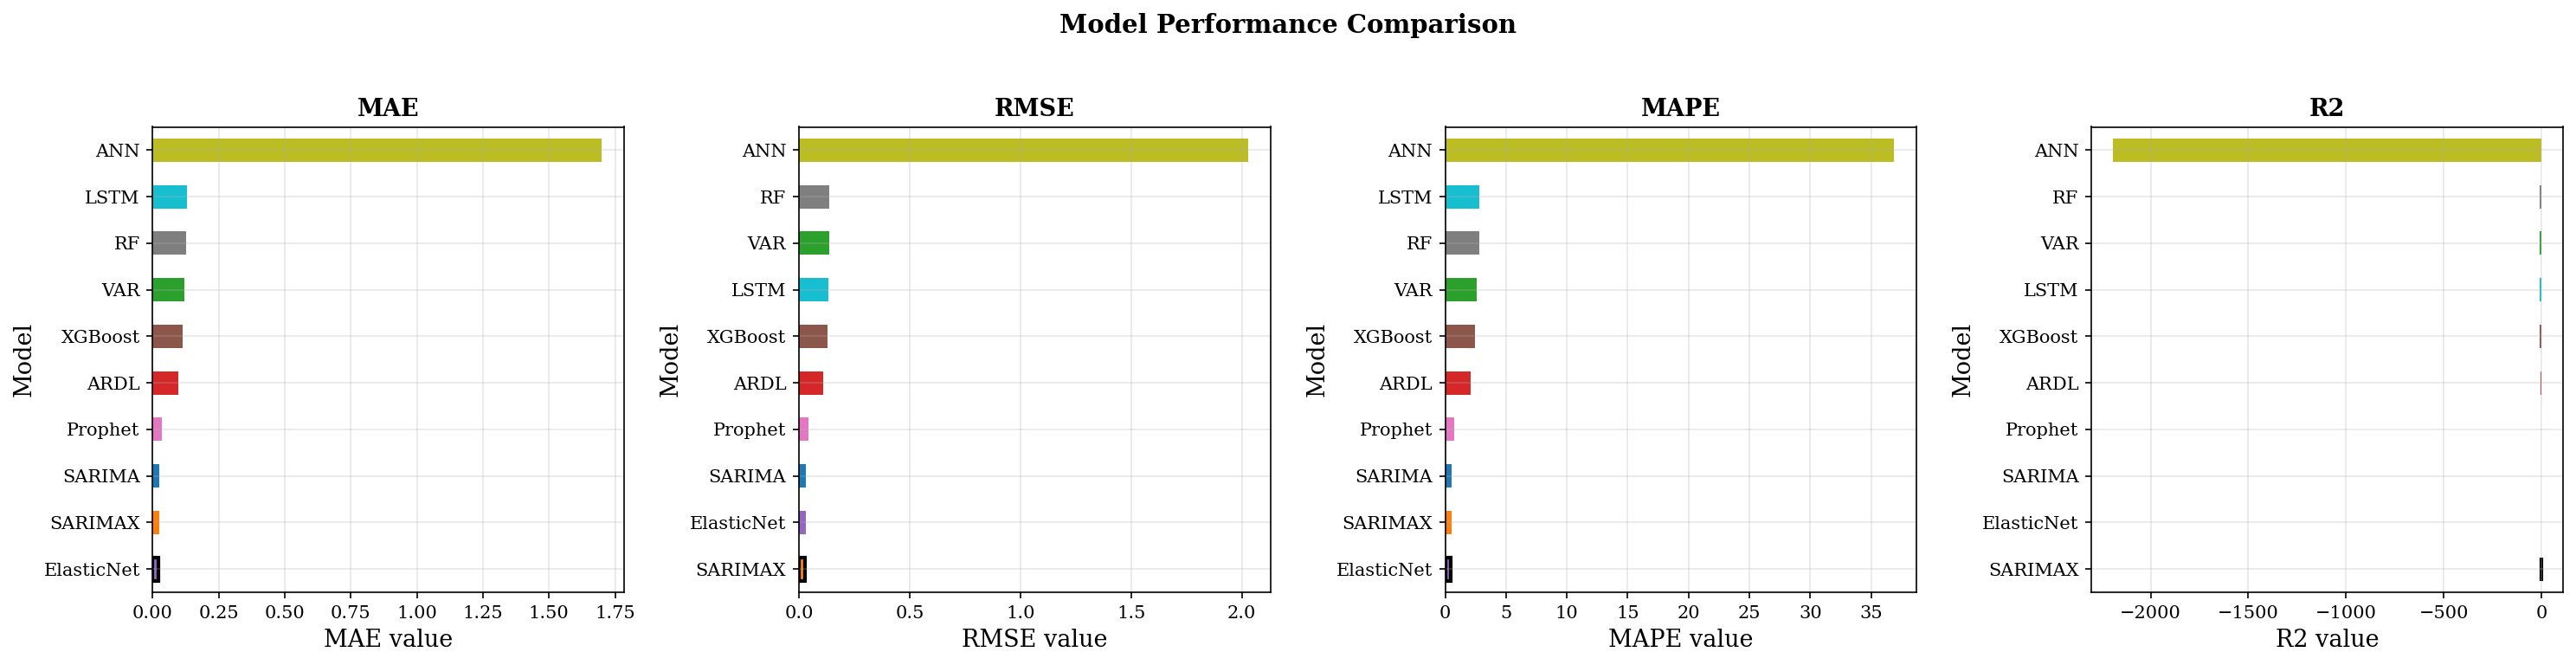

In [62]:
# ============================================================
# Cell 27: Metrics Bar Chart Comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
for ax, metric in zip(axes, metrics):
    data = results_df[metric].sort_values(
        ascending=(metric != 'R2'))
    colors = [PALETTE.get(m, '#333') for m in data.index]
    data.plot.barh(ax=ax, color=colors)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xlabel(f'{metric} value')
    # Highlight best
    best_idx = 0
    ax.get_children()[best_idx].set_edgecolor('black')
    ax.get_children()[best_idx].set_linewidth(2)

fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + 'metrics_comparison.png')
plt.show()

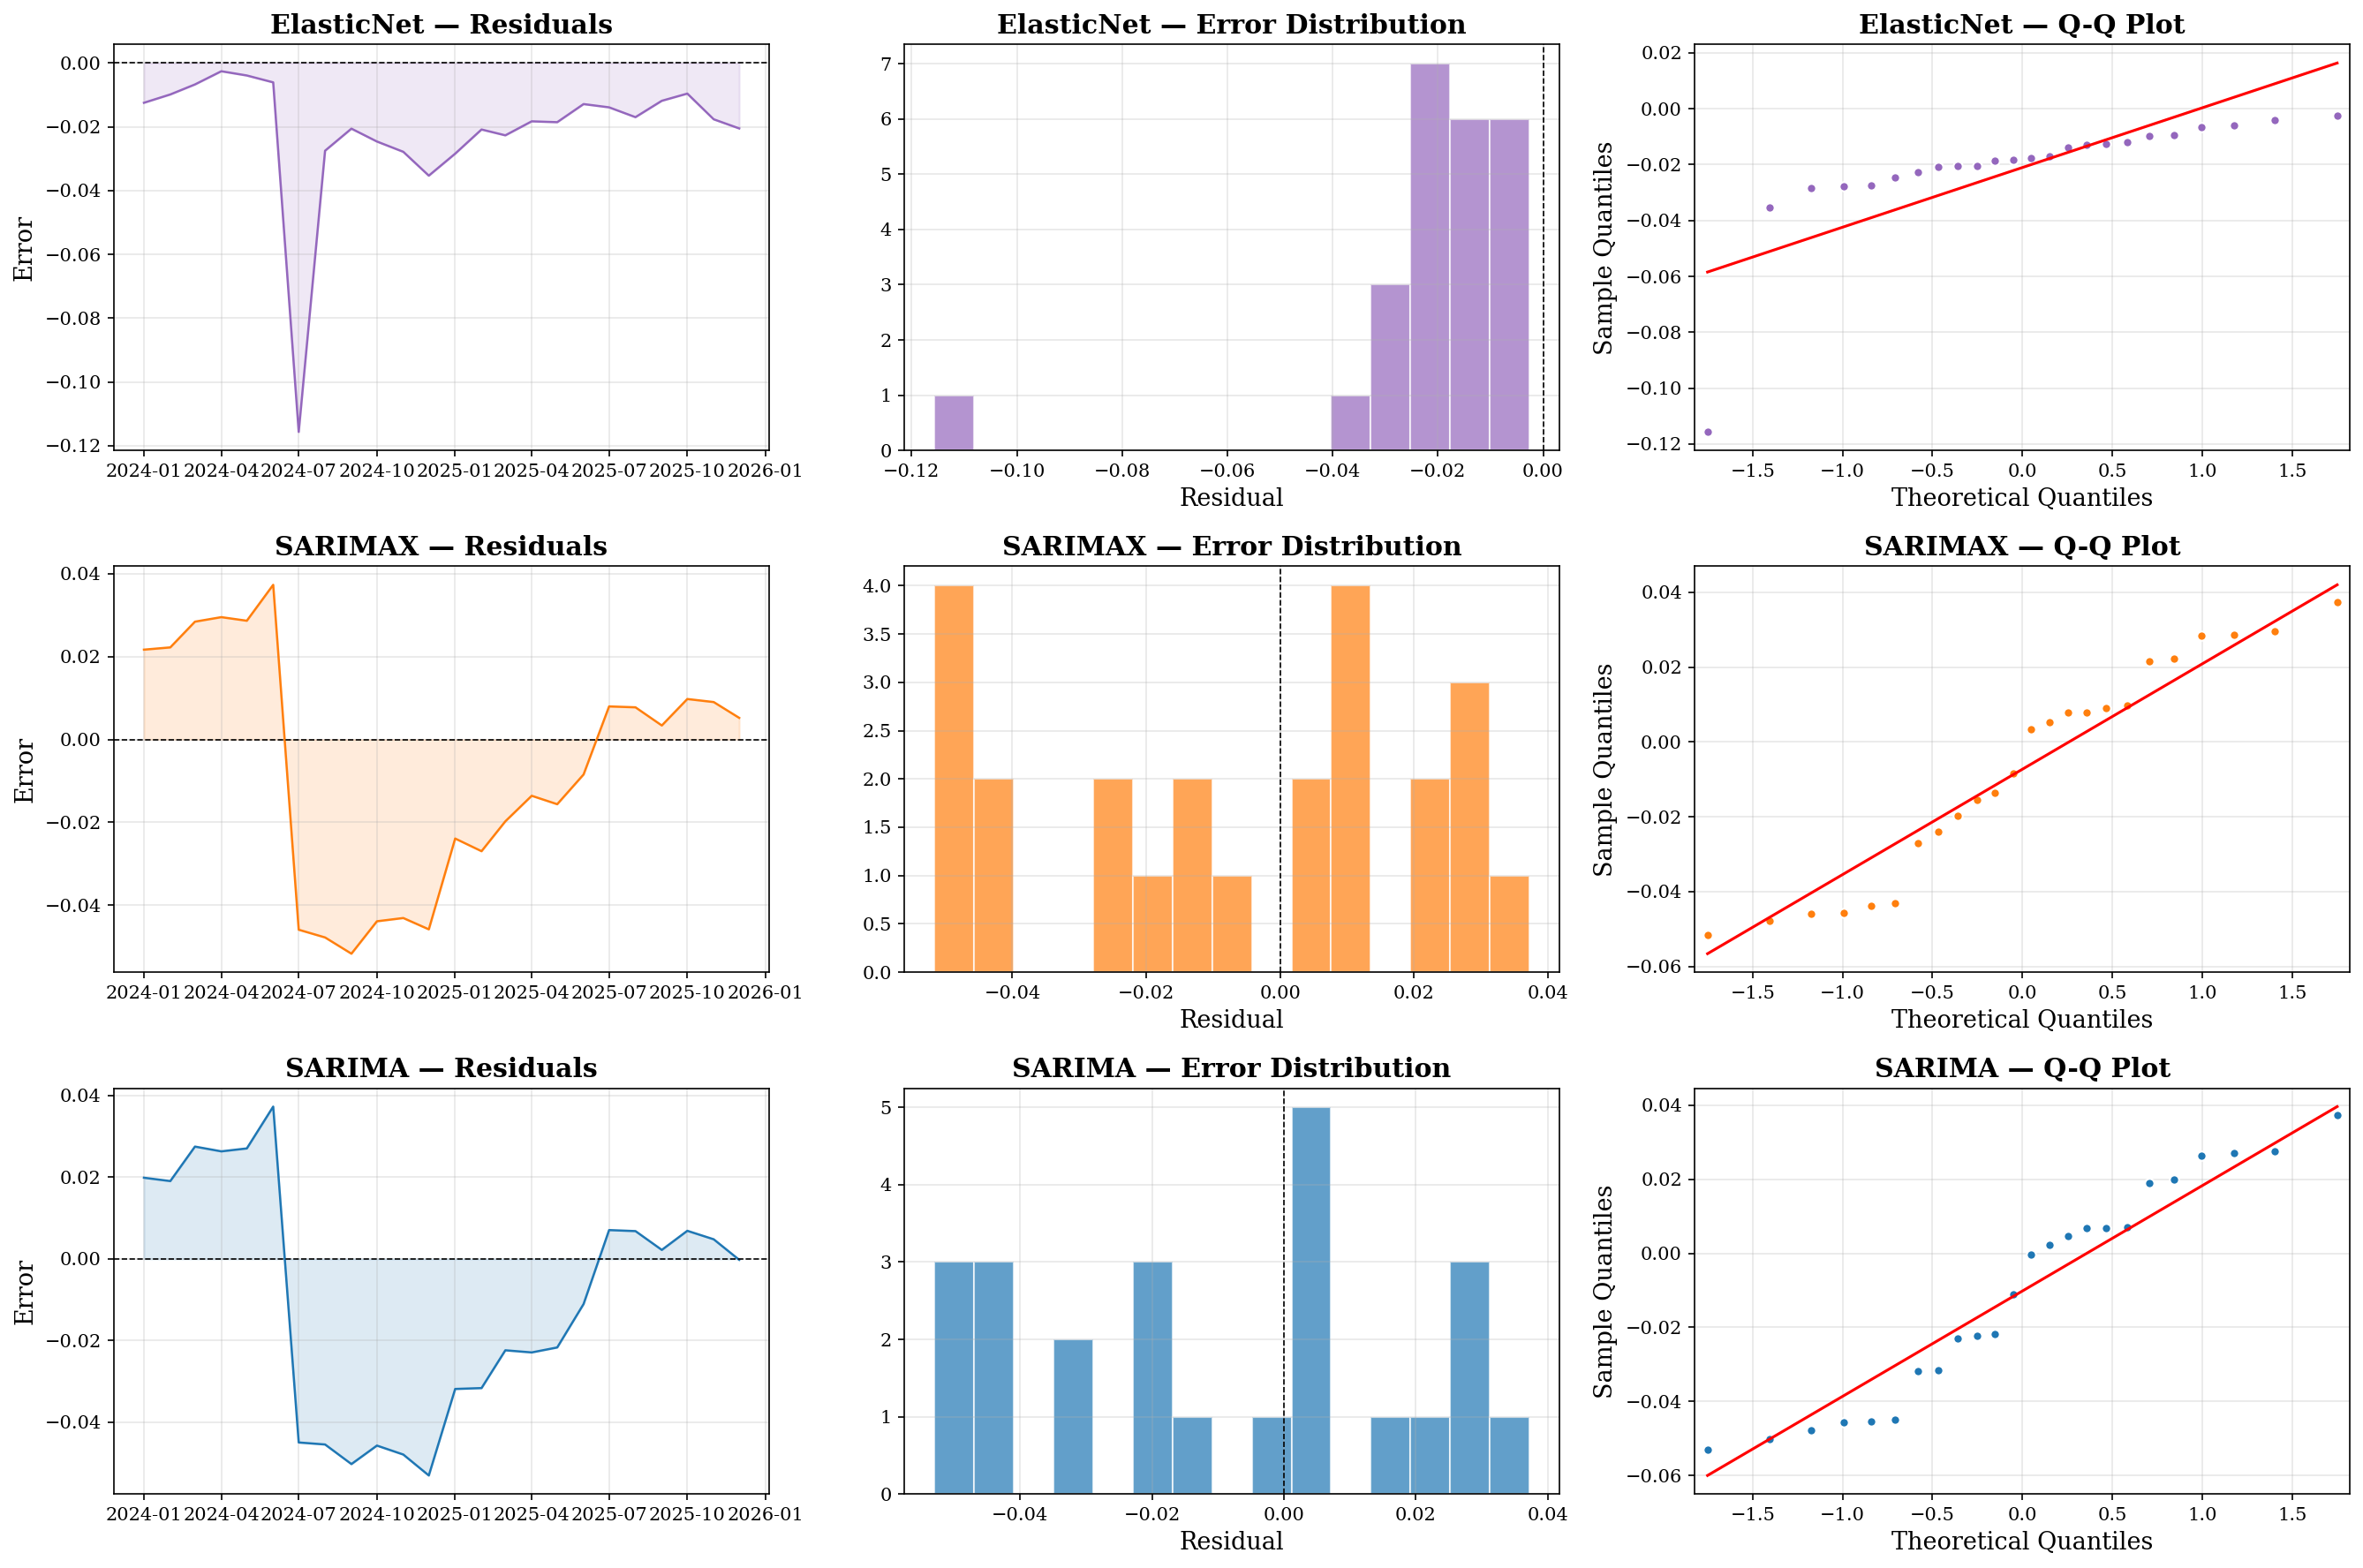

In [63]:
# ============================================================
# Cell 28: Residual Analysis — Top 3 Models
# ============================================================
top3 = results_df.head(3).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, name in enumerate(top3):
    pred = forecasts[name]
    common_idx = y_test.index.intersection(pred.index)
    residuals = y_test.loc[common_idx] - pred.loc[common_idx]
    color = PALETTE.get(name, '#333')
    
    # Residual time series
    axes[i, 0].plot(common_idx, residuals, color=color, lw=1.2)
    axes[i, 0].axhline(0, color='k', ls='--', lw=0.8)
    axes[i, 0].fill_between(common_idx, residuals, alpha=0.15, color=color)
    axes[i, 0].set_title(f'{name} — Residuals', fontweight='bold')
    axes[i, 0].set_ylabel('Error')
    
    # Histogram
    axes[i, 1].hist(residuals, bins=15, color=color, alpha=0.7, edgecolor='white')
    axes[i, 1].axvline(0, color='k', ls='--', lw=0.8)
    axes[i, 1].set_title(f'{name} — Error Distribution', fontweight='bold')
    axes[i, 1].set_xlabel('Residual')
    
    # Q-Q plot
    sm.qqplot(residuals, line='s', ax=axes[i, 2], color=color,
              markerfacecolor=color, markeredgecolor='white', markersize=5)
    axes[i, 2].set_title(f'{name} — Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES + 'residual_analysis.png')
plt.show()

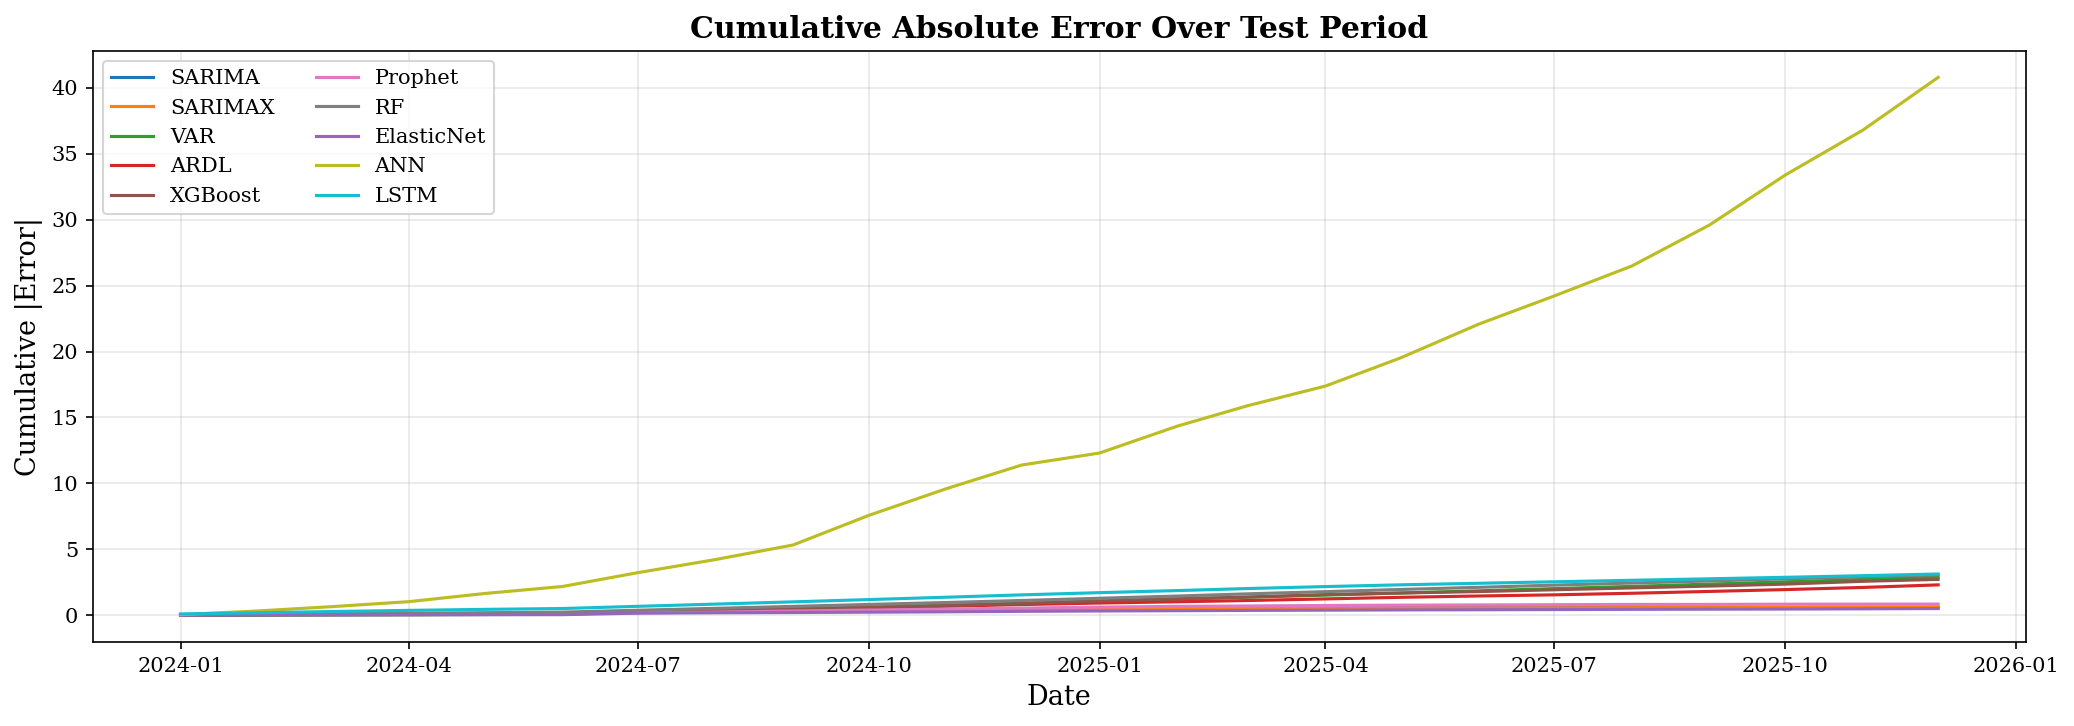

In [64]:
# ============================================================
# Cell 29: Cumulative Error Plot
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

for name, pred in forecasts.items():
    common_idx = y_test.index.intersection(pred.index)
    cum_abs_err = np.abs(y_test.loc[common_idx] - pred.loc[common_idx]).cumsum()
    color = PALETTE.get(name, '#333')
    ax.plot(common_idx, cum_abs_err, lw=1.5, label=name, color=color)

ax.set_title('Cumulative Absolute Error Over Test Period', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative |Error|')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(FIGURES + 'cumulative_error.png')
plt.show()

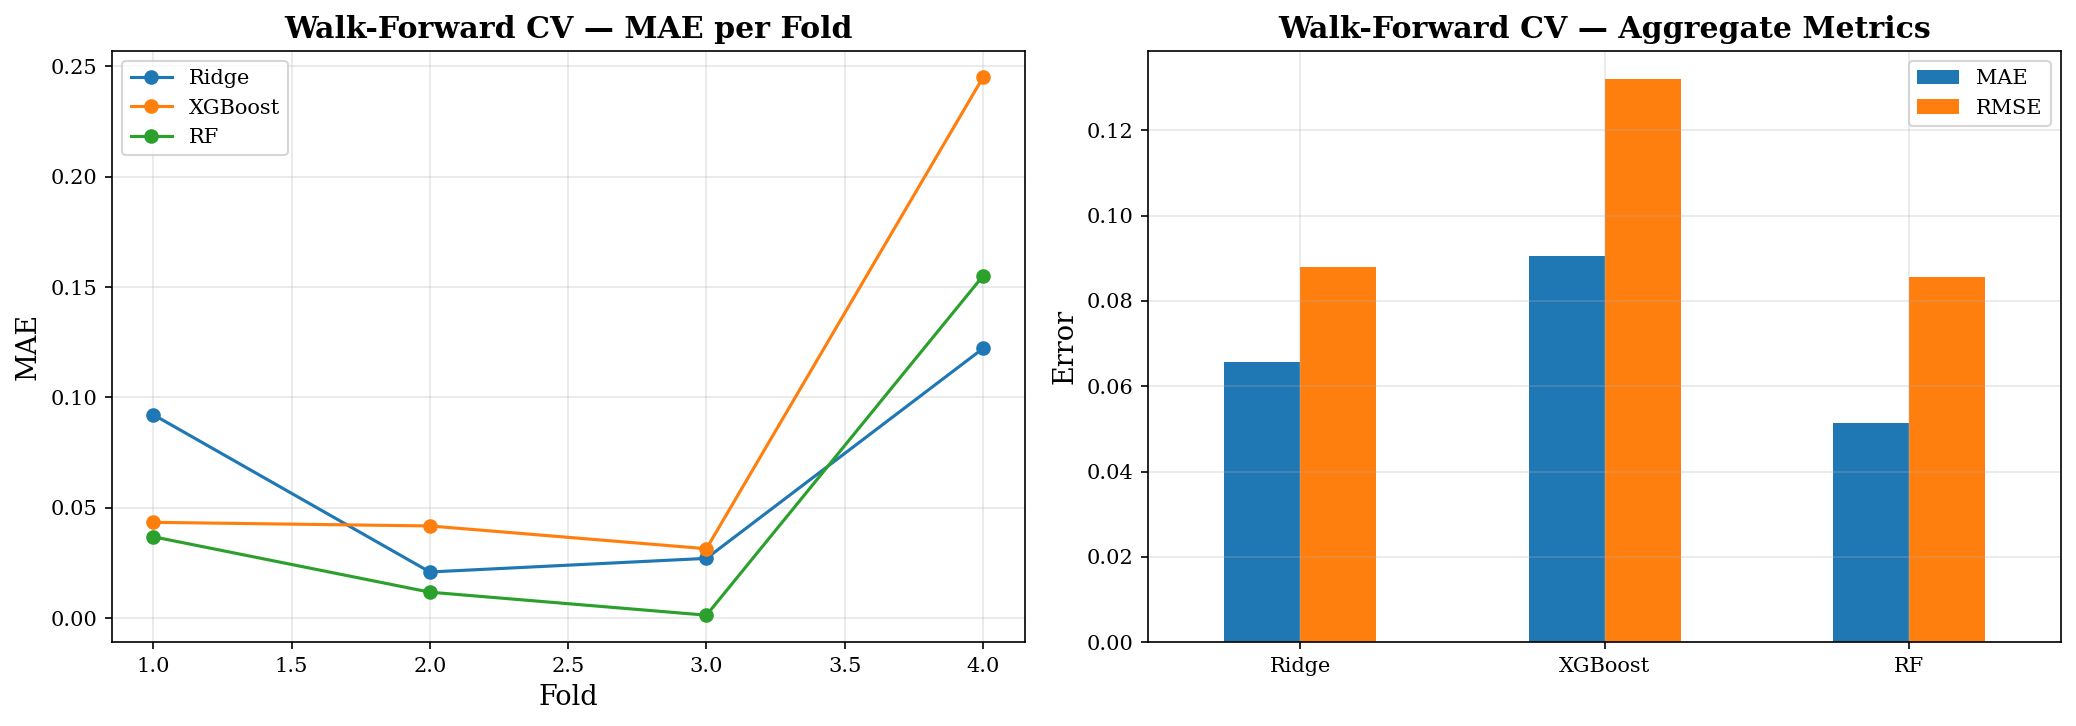


Walk-Forward CV Summary:


,MAE,RMSE
Ridge,0.0656,0.0878
XGBoost,0.0904,0.1321
RF,0.0513,0.0857


In [65]:
# ============================================================
# Cell 30: Walk-Forward CV Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE across folds
for name, wf in wf_results.items():
    folds = wf['folds']
    axes[0].plot(folds['Fold'], folds['MAE'], 'o-', label=name, lw=1.5)
axes[0].set_title('Walk-Forward CV — MAE per Fold', fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('MAE')
axes[0].legend()

# Aggregate comparison
wf_agg = pd.DataFrame({name: {'MAE': wf['agg_MAE'], 'RMSE': wf['agg_RMSE']}
                        for name, wf in wf_results.items()}).T
wf_agg.plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Walk-Forward CV — Aggregate Metrics', fontweight='bold')
axes[1].set_ylabel('Error')

plt.tight_layout()
plt.savefig(FIGURES + 'walkforward_cv.png')
plt.show()

print('\nWalk-Forward CV Summary:')
display(wf_agg.round(4))

In [66]:
# ============================================================
# Cell 31: Export Results for LaTeX
# ============================================================

# Export metrics table as LaTeX
latex_table = results_df.round(4).to_latex(
    caption='Out-of-Sample Model Performance Comparison (2024--2025)',
    label='tab:model_comparison',
    column_format='l' + 'r' * len(results_df.columns),
    bold_rows=True,
)

with open('report/metrics_table.tex', 'w') as f:
    f.write(latex_table)

# Export walk-forward CV as LaTeX
wf_latex = wf_agg.round(4).to_latex(
    caption='Walk-Forward Cross-Validation Results',
    label='tab:walkforward_cv',
)
with open('report/walkforward_table.tex', 'w') as f:
    f.write(wf_latex)

# Export stationarity tests as LaTeX
stat_latex = stat_df.to_latex(
    caption='Stationarity Test Results (ADF + KPSS)',
    label='tab:stationarity',
    index=False,
)
with open('report/stationarity_table.tex', 'w') as f:
    f.write(stat_latex)

print('LaTeX tables exported to report/ directory.')
print('  - report/metrics_table.tex')
print('  - report/walkforward_table.tex')
print('  - report/stationarity_table.tex')

FileNotFoundError: [Errno 2] No such file or directory: 'report/metrics_table.tex'

---
## 7. Data Sufficiency Assessment

### Summary

| Criterion | Status | Notes |
|-----------|--------|-------|
| Sample size ($n=192$) | Adequate | Exceeds $5p$ rule for SARIMAX; tight for LSTM |
| Frequency | Monthly | Appropriate for macro forecasting |
| Target stationarity | First-difference stationary | $I(1)$ process |
| Exogenous coverage | Good | Oil, FX, rates, gold, CPI (via PCA) |
| Structural breaks | Handled | Regime dummies for 3 major events |
| Seasonality | Captured | Fourier terms + seasonal ARIMA components |
| Missing indicators | Medium priority | STEI, Industrial Production, Retail Trade |
| Regional data | Not needed | National-level sufficient for diploma scope |

### Recommendations for Defense

1. **Emphasize the hybrid approach**: Comparing 10 models (classical + ML + DL) demonstrates methodological rigor.
2. **Walk-forward CV**: This is the gold standard validation for time-series. Highlight that standard k-fold would cause data leakage.
3. **Structural breaks**: The regime dummies show awareness of Kazakhstan's economic context.
4. **Feature engineering depth**: Fourier terms, PCA, interactions, and Granger-informed lags go well beyond basic approaches.
5. **Future work**: Mention STEI integration, ensemble stacking, and regional panel modeling.